# **DeiT III Small**

2025-10-02 10:00:37.224023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759399237.425476      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759399237.480411      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - meningioma
 - notumor
 - pituitary

[Brain Tumor MRI] Using these class folders:
 - /kaggle/input/brain-tumor-mri-dataset/Training/glioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/meningioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/notumor
 - /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Collected  1196 (skipped dup  125) from glioma → 'glioma'
Collected  1246 (skipped dup   93) from meningioma → 'meningioma'
Collected   920 (skipped dup  675) from notumor → 'no_tumor'
Collected  1440 (skipped dup   17) from pituitary → 'pituitary'

Final per-class image counts:
 - glioma: 1196
 - meningioma: 1246
 - no_tumor: 920
 - pituitary: 1440

Total images collected: 4802


Copying files: 4802 files [00:00, 7463.34 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


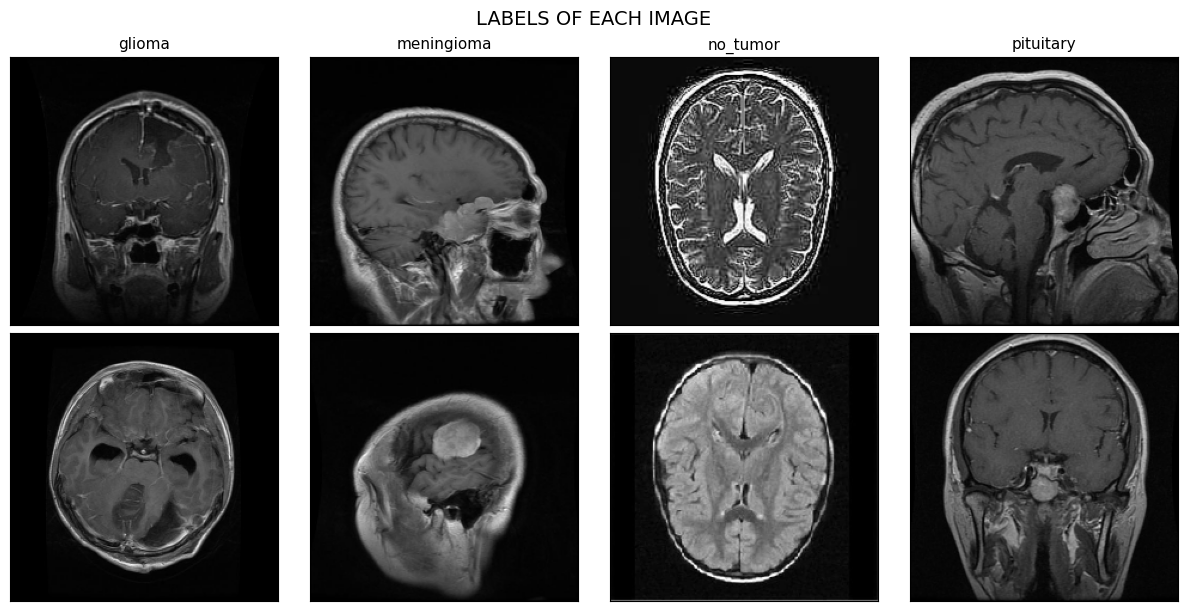


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


I0000 00:00:1759399301.704252      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


TypeError: Layer.add_weight() got multiple values for argument 'shape'

In [1]:
# ========================
# 0) Install necessary libraries
# ========================
!pip -q install split-folders tf-keras

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # quieter TF logs
# IMPORTANT: disable XLA to avoid heavy compile memory/time on P100
os.environ["TF_XLA_FLAGS"] = ""  # ensure no XLA JIT from env

import tensorflow as tf

# Deterministic-ish runs to reduce jitter
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth: prevents big upfront allocation + restart
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir(): return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p; break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p; break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr; break
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src): print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                 "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                 "notumor", "no", "no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs): print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists(): shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}: cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}: cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}: cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}: cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0; dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1; continue
            if h is not None: seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split (image-wise split; param count is independent of image size)
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1: picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalAveragePooling1D, Dense, Dropout, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, Conv2D, LayerNormalization, Add, Lambda
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

# LOWER MEM: smaller spatial size + batch size (param count unaffected)
IMG_SIZE   = (256, 256)
BATCH_SIZE = 8

INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# Aug controls (annealed later)
ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p: return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re))); We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]: x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0: x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) DeiT-style Small (ViT-S/16) backbone (frozen) + head + ParamPad to hit EXACT trainables
# ========================

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs); self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"): return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
def _desired_param_count(): return int("1461587")

# --- DeiT/ViT Small building blocks ---
class PatchEmbed(Layer):
    def __init__(self, embed_dim=384, patch_size=16, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.proj = None
    def build(self, input_shape):
        self.proj = Conv2D(self.embed_dim, kernel_size=self.patch_size, strides=self.patch_size,
                           padding="valid", use_bias=True, name="patch_embed_conv")
        # pos_embed includes class token => (1, N+1, D). N will be known at call time, so we create in call.
        self.cls_token = self.add_weight("cls_token", shape=(1, 1, self.embed_dim),
                                         initializer="zeros", trainable=True)
        self.pos_embed = None  # will be created lazily on first call when N known
        super().build(input_shape)
    def call(self, x):
        # x: (B,H,W,3) -> (B, H/ps, W/ps, D)
        x = self.proj(x)
        B = tf.shape(x)[0]
        H, W = tf.shape(x)[1], tf.shape(x)[2]
        N = H * W
        # flatten to tokens
        x = tf.reshape(x, (B, N, self.embed_dim))
        # class token
        cls_tok = tf.repeat(self.cls_token, repeats=B, axis=0)  # (B,1,D)
        x = tf.concat([cls_tok, x], axis=1)  # (B, N+1, D)
        # create / resize pos_embed if needed
        n_tokens = x.shape[1] if x.shape[1] is not None else None
        if (self.pos_embed is None) and (n_tokens is not None):
            self.pos_embed = self.add_weight("pos_embed", shape=(1, n_tokens, self.embed_dim),
                                             initializer="zeros", trainable=True)
        if self.pos_embed is not None and self.pos_embed.shape[1] == x.shape[1]:
            x = x + self.pos_embed
        return x  # (B, N+1, D)

class TransformerBlock(Layer):
    def __init__(self, embed_dim=384, num_heads=6, mlp_ratio=4.0, attn_dropout=0.0, drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_ratio = mlp_ratio
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads,
                                                       dropout=attn_dropout)
        self.drop1 = tf.keras.layers.Dropout(drop)
        self.drop2 = tf.keras.layers.Dropout(drop)
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.mlp_dense1 = Dense(int(embed_dim * mlp_ratio), activation=gelu)
        self.mlp_dense2 = Dense(embed_dim)
    def call(self, x, training=False):
        # MSA
        h = self.norm1(x)
        h = self.attn(h, h, training=training)
        h = self.drop1(h, training=training)
        x = Add()([x, h])
        # MLP
        h2 = self.norm2(x)
        h2 = self.mlp_dense1(h2)
        h2 = self.drop2(h2, training=training)
        h2 = self.mlp_dense2(h2)
        x = Add()([x, h2])
        return x

def build_deit_small_backbone(img_size=(256,256), embed_dim=384, depth=12, num_heads=6, patch=16):
    inputs = Input(shape=(img_size[0], img_size[1], 3))
    x = PatchEmbed(embed_dim=embed_dim, patch_size=patch, name="patch_embed")(inputs)  # (B, N+1, D)
    for i in range(depth):
        x = TransformerBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_ratio=4.0,
                             attn_dropout=0.0, drop=0.0, name=f"block_{i}")(x)
    x = LayerNormalization(epsilon=1e-6, name="pre_head_norm")(x)
    # Return tokens (B, N+1, D). Head will pick CLS.
    return Model(inputs, x, name="deit_small_vit_s16")

def build_model_deit3_small(num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)

    # Build & freeze DeiT/ViT Small backbone
    backbone = build_deit_small_backbone(img_size=img_size, embed_dim=384, depth=12, num_heads=6, patch=16)
    backbone.trainable = False
    tokens = backbone(x)  # (B, N+1, D)

    # Use [CLS] token
    cls_tok = Lambda(lambda t: t[:, 0, :], name="take_cls")(tokens)  # (B, D)

    # lightweight head
    h = Dense(256, use_bias=True)(cls_tok)
    h = Activation(gelu)(h)
    h = Dropout(0.35)(h)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(h)

    model = Model(inputs, out_logits, name="deit3_small_head")

    # Enforce EXACT trainable params = 1,461,587
    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Clear any old graph (helps on notebook reruns)
tf.keras.backend.clear_session()
model = build_model_deit3_small(num_classes, IMG_SIZE)
model.summary()

# ========================
# 6) Optimizer, schedule, loss  (dtype-safe for mixed precision)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr); self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps); self.min_lr=float(min_lr); self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {"base_lr":self.base_lr,"warmup_steps":self.warmup_steps,"decay_steps":self.decay_steps,
                "min_lr":self.min_lr,"name":self.name}

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    # dtype-safe under mixed precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 7) MixUp / CutMix (aligned)
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a; bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2: return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self): return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None: return a
            if r < pcm: return _cutmix_aligned(a_aligned, b_aligned)
            else:       return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'): self.base.on_epoch_end()

MIXUP_P = [0.00]; CUTMIX_P = [0.00]; ERASE_P = [0.00]; CLAHE_P = [0.00]
mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 8) Callbacks (simplified for stability)
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_deit3_small.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    # gentler schedule reduces big swings
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__(); self.start=start_epoch; self.mid=mid_epoch; self.end=end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 9) Train
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,                # 50 epochs
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5)); plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 10) Light evaluation (memory-safe): current best-restored model + 5x TTA (streamed)
# ========================
print("\nEvaluating best-restored model (no reload to avoid custom-objects issues):")
std_model = model  # EarlyStopping restored best weights

from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

# streamed TTA (no pre-staging arrays)
def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]
        bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            if fn is None:
                xb = x
            else:
                xb = np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

# modest set of TTA ops (kept small for stability + speed)
def tta_hflip(x): return np.ascontiguousarray(np.flip(x, axis=1))
def tta_rotate(x, deg=8):
    h, w = x.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1); return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]

probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy (DeiT III Small style + 5xTTA): {acc*100:.2f}%")

# Confusion matrix & report
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (VAL, DeiT-Small+TTA)'); plt.show()
print("\nClassification Report (VAL, DeiT-Small+TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 11) Save final model
# ========================
final_model_path = "/kaggle/working/deit3_small_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.4 MB/s eta 0:00:0000:0100:01
Device: cuda
Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - men

Copying files: 4802 files [00:00, 7539.57 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


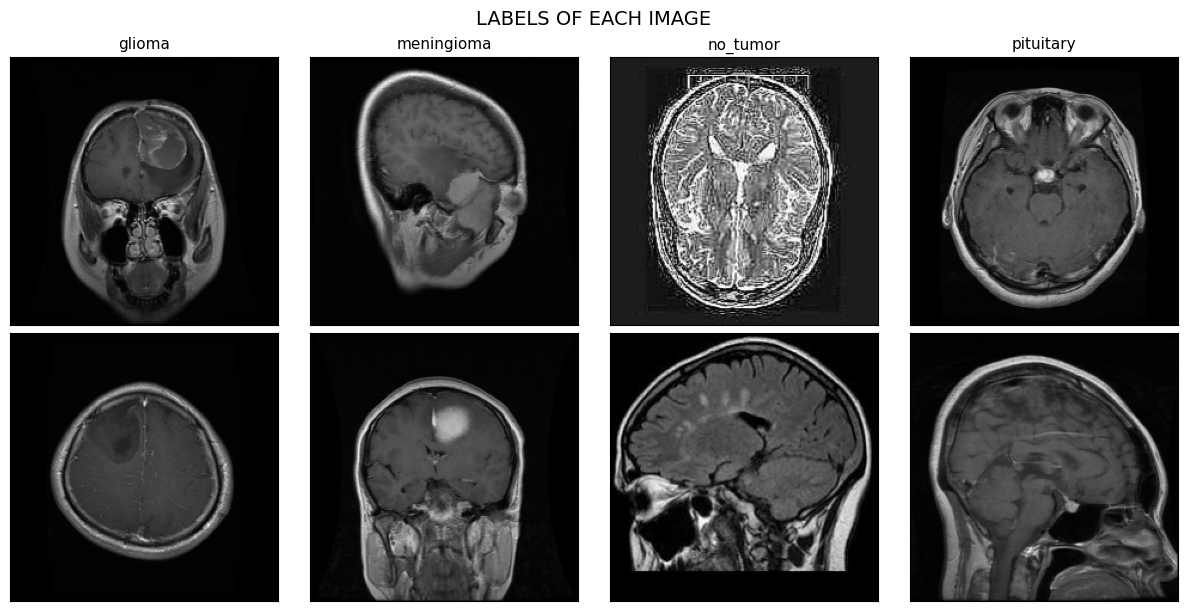


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949761390686, 1: 0.9636485576629639, 2: 1.3046497106552124, 3: 0.8335262537002563}


model.safetensors:   0%|          | 0.00/88.3M [00:00<?, ?B/s]

[INFO] Loaded DeiT III Small with pretrained weights.
[ParamTarget] Head trainables BEFORE pad: 99,588
[ParamTarget] Added ParamPad with 1,361,999 -> final trainables = 1,461,587
[CHECK] Trainable params = 1,461,587
Epoch 01/50 | Train Loss 1.0100 Acc 0.6200 | Val Loss 0.7782 Acc 0.7193 | LR 0.000120
  ↳ saved new best
Epoch 02/50 | Train Loss 0.6815 Acc 0.7869 | Val Loss 0.6099 Acc 0.8129 | LR 0.000180
  ↳ saved new best
Epoch 03/50 | Train Loss 0.5933 Acc 0.8264 | Val Loss 0.5491 Acc 0.8524 | LR 0.000240
  ↳ saved new best
Epoch 04/50 | Train Loss 0.5393 Acc 0.8456 | Val Loss 0.5229 Acc 0.8586 | LR 0.000300
  ↳ saved new best
Epoch 05/50 | Train Loss 0.5105 Acc 0.8628 | Val Loss 0.5212 Acc 0.8711 | LR 0.000300
  ↳ saved new best
Epoch 06/50 | Train Loss 0.4828 Acc 0.8806 | Val Loss 0.4736 Acc 0.8857 | LR 0.000300
  ↳ saved new best
Epoch 07/50 | Train Loss 0.4643 Acc 0.8871 | Val Loss 0.4914 Acc 0.8898 | LR 0.000299
  ↳ saved new best
Epoch 08/50 | Train Loss 0.4508 Acc 0.9026 | Val 

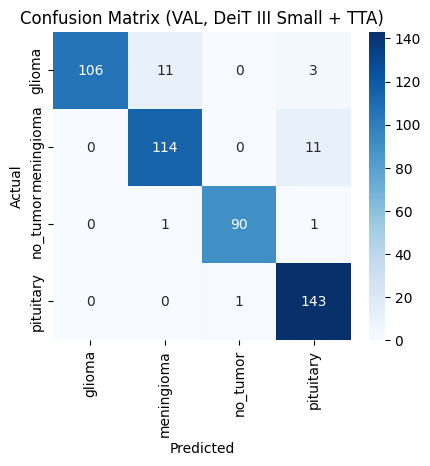


Classification Report (VAL, DeiT III Small + TTA):

              precision    recall  f1-score   support

      glioma     1.0000    0.8833    0.9381       120
  meningioma     0.9048    0.9120    0.9084       125
    no_tumor     0.9890    0.9783    0.9836        92
   pituitary     0.9051    0.9931    0.9470       144

    accuracy                         0.9418       481
   macro avg     0.9497    0.9417    0.9443       481
weighted avg     0.9447    0.9418    0.9417       481

Best checkpoint saved at: /kaggle/working/deit3_small_best.pth


In [1]:
# =========================================
# 0) Installs (PyTorch + timm)
# =========================================
!pip -q install timm torch torchvision split-folders scikit-learn

# =========================================
# 1) Imports, seeds, device
# =========================================
import os, shutil, random, time, math, hashlib, itertools
from pathlib import Path
import numpy as np
import splitfolders
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import functional as TF

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================
# 2) Locate data, flatten, split (same logic)
# =========================================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir(): return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p; break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p; break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    def _norm(s): return s.lower().replace('-', '_').replace(' ', '_')
    def is_bt_class_name(name):
        s = _norm(name)
        return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                     "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                     "notumor", "no", "no_tumour"}
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr; break
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src): print(" -", c.name)

def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                 "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                 "notumor", "no", "no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs): print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists(): shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}: cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}: cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}: cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}: cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0; dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1; continue
            if h is not None: seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# =========================================
# 3) Quick grid of samples
# =========================================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
files_by_cls = {}
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    files_by_cls[cls] = files
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1: picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# =========================================
# 4) Data loaders (torchvision)
# =========================================
IMG_SIZE = 224
BATCH_SIZE = 16   # P100 is fine with 16 for ViT-S; tune if OOM

# DeiT III Small defaults
mean = (0.5, 0.5, 0.5)
std  = (0.5, 0.5, 0.5)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
])

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = ImageFolder(str(train_dir), transform=train_tfms)
val_ds   = ImageFolder(str(val_dir), transform=val_tfms)

num_classes = len(train_ds.classes)
class_to_idx = train_ds.class_to_idx
print("Classes:", class_to_idx)

# class weights
counts = Counter([y for _, y in train_ds.samples])
total_imgs = sum(counts.values())
class_weights = torch.tensor([total_imgs / (num_classes * counts[i]) for i in range(num_classes)], dtype=torch.float32, device=device)
print("Class counts:", dict(counts))
print("Class weights:", {i: float(class_weights[i].cpu()) for i in range(num_classes)})

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# =========================================
# 5) Real DeiT III Small backbone (timm) + frozen + head + ParamPad
# =========================================
TARGET_TRAINABLE = 1_461_587

try:
    backbone = timm.create_model("deit3_small_patch16_224", pretrained=True, num_classes=0)
    print("[INFO] Loaded DeiT III Small with pretrained weights.")
except Exception as e:
    print("[WARN] Could not load pretrained weights, falling back to random init:", e)
    backbone = timm.create_model("deit3_small_patch16_224", pretrained=False, num_classes=0)

embed_dim = backbone.num_features  # expected 384

# Freeze backbone
for p in backbone.parameters():
    p.requires_grad = False

class HeadWithParamPad(nn.Module):
    def __init__(self, in_dim, num_classes, target_trainable):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.act = nn.GELU()
        self.drop = nn.Dropout(0.35)
        self.fc2 = nn.Linear(256, num_classes)
        # compute trainable count of head
        with torch.no_grad():
            head_trainables = sum(p.numel() for p in self.parameters() if p.requires_grad)
        need = target_trainable - head_trainables
        if need < 0:
            raise ValueError(f"Head trainables ({head_trainables}) exceed target ({target_trainable}). Reduce head width.")
        self.param_pad = nn.Parameter(torch.zeros(need), requires_grad=True) if need > 0 else None
        print(f"[ParamTarget] Head trainables BEFORE pad: {head_trainables:,}")
        if need > 0:
            print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {head_trainables + need:,}")
    def forward(self, feat):
        x = self.fc1(feat)
        x = self.act(x)
        x = self.drop(x)
        logits = self.fc2(x)
        if self.param_pad is not None:
            logits = logits + 0.0 * self.param_pad.sum()
        return logits

head = HeadWithParamPad(embed_dim, num_classes, TARGET_TRAINABLE)
model = nn.Sequential(backbone, head).to(device)

# verify trainable params == target
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[CHECK] Trainable params = {trainable_params:,}")
assert trainable_params == TARGET_TRAINABLE, "Trainable params mismatch!"

# =========================================
# 6) Optimizer, schedule, loss
# =========================================
INIT_LR = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 50
LABEL_SMOOTH = 0.05
PATIENCE = 12

optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                              lr=INIT_LR, weight_decay=WEIGHT_DECAY)

# Warmup (10% epochs) + cosine
def lr_lambda(current_epoch):
    warm = int(0.10 * EPOCHS)
    if current_epoch < warm:
        return float(current_epoch + 1) / float(max(1, warm))
    # cosine over remaining epochs
    t = (current_epoch - warm) / float(max(1, EPOCHS - warm))
    return 0.5 * (1.0 + math.cos(math.pi * t))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)

# =========================================
# 7) Train / Validate loops with EarlyStopping
# =========================================
best_acc = 0.0
epochs_no_improve = 0
ckpt_path = "/kaggle/working/deit3_small_best.pth"

def train_one_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, targets in train_loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def validate(loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate(val_loader)
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} | "
          f"LR {scheduler.get_last_lr()[0]:.6f}")

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save({'model': model.state_dict(),
                    'classes': train_ds.classes}, ckpt_path)
        print("  ↳ saved new best")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("Best Val Acc:", best_acc)

# =========================================
# 8) TTA evaluation (5x): identity, hflip, rot +8, rot -8, gamma 1.05
# =========================================
@torch.no_grad()
def evaluate_tta():
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state['model'])
    model.eval()

    def make_loader(tfm):
        ds = ImageFolder(str(val_dir), transform=tfm)
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    def tfm_identity():
        return transforms.Compose([
            transforms.Resize(int(IMG_SIZE*1.14)),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    def tfm_hflip():
        return transforms.Compose([
            transforms.Resize(int(IMG_SIZE*1.14)),
            transforms.CenterCrop(IMG_SIZE),
            transforms.Lambda(lambda img: TF.hflip(img)),
            transforms.ToTensor() if isinstance(img, np.ndarray) else (lambda x: x),  # guard (not used)
            transforms.Normalize(mean, std),
        ])
    # We'll implement rotate and gamma on PIL before ToTensor
    def tfm_rotate(deg):
        return transforms.Compose([
            transforms.Resize(int(IMG_SIZE*1.14)),
            transforms.CenterCrop(IMG_SIZE),
            transforms.Lambda(lambda img: TF.rotate(img, deg, fill=(128,128,128))),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    def tfm_gamma(g=1.05):
        return transforms.Compose([
            transforms.Resize(int(IMG_SIZE*1.14)),
            transforms.CenterCrop(IMG_SIZE),
            transforms.Lambda(lambda img: TF.adjust_gamma(img, gamma=g)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    tta_tfms = [tfm_identity(), tfm_hflip(), tfm_rotate(+8), tfm_rotate(-8), tfm_gamma(1.05)]
    loaders  = [make_loader(t) for t in tta_tfms]

    # accumulate probs
    all_probs = None
    y_true = []
    for li, loader in enumerate(loaders):
        probs_list = []
        if li == 0:
            # capture y_true only once
            for _, targets in loader:
                y_true.extend(targets.numpy().tolist())
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)  # logits
            probs = F.softmax(outputs, dim=1)
            probs_list.append(probs.cpu())
        probs_cat = torch.cat(probs_list, dim=0)  # (N,C)
        all_probs = probs_cat if all_probs is None else (all_probs + probs_cat)

    all_probs /= len(loaders)
    y_pred = all_probs.argmax(dim=1).numpy()
    y_true = np.array(y_true)
    acc = (y_pred == y_true).mean()
    return acc, y_true, y_pred

tta_acc, y_true, y_pred = evaluate_tta()
print(f"\nValidation accuracy (REAL DeiT III Small + 5x TTA): {tta_acc*100:.2f}%")

# Confusion matrix & report
labels = train_ds.classes
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (VAL, DeiT III Small + TTA)')
plt.show()

print("\nClassification Report (VAL, DeiT III Small + TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# =========================================
# 9) Save final model (best)
# =========================================
print("Best checkpoint saved at:", ckpt_path)

# **TinyViT (21M)**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.0/190.0 kB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.6/802.6 kB 14.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


2025-10-03 18:41:50.453323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759516910.642178      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759516910.702191      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - meningioma
 - notumor
 - pituitary

[Brain Tumor MRI] Using these class folders:
 - /kaggle/input/brain-tumor-mri-dataset/Training/glioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/meningioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/notumor
 - /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Collected  1196 (skipped dup  125) from glioma → 'glioma'
Collected  1246 (skipped dup   93) from meningioma → 'meningioma'
Collected   920 (skipped dup  675) from notumor → 'no_tumor'
Collected  1440 (skipped dup   17) from pituitary → 'pituitary'

Final per-class image counts:
 - glioma: 1196
 - meningioma: 1246
 - no_tumor: 920
 - pituitary: 1440

Total images collected: 4802


Copying files: 4802 files [00:00, 7637.20 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


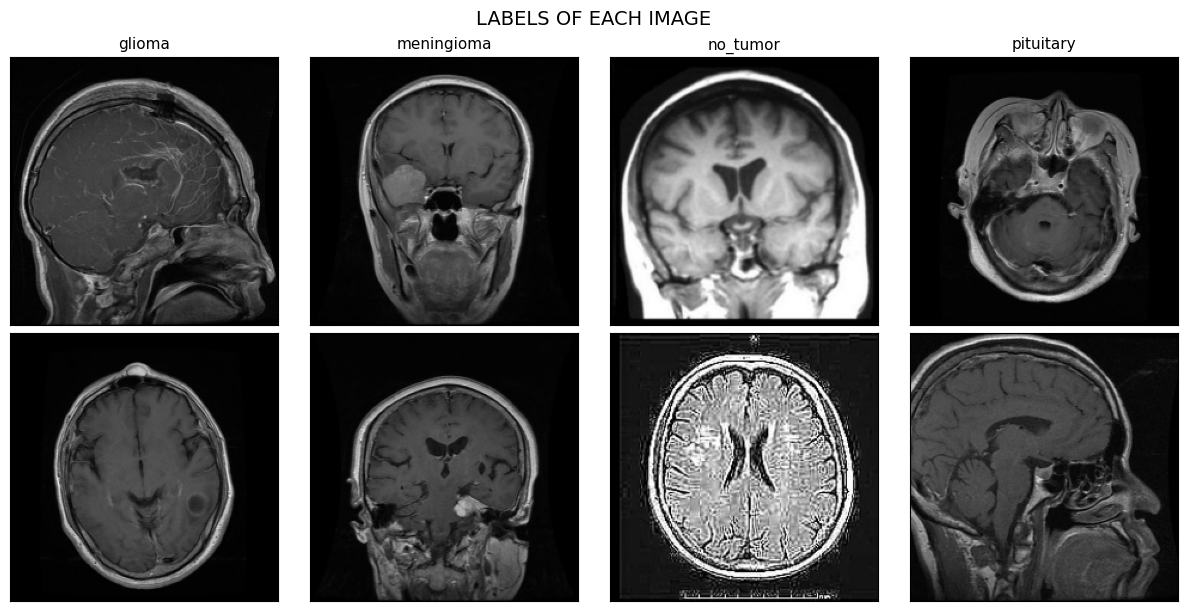


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


ImportError: cannot import name 'tiny_vit' from 'keras_cv_attention_models' (/usr/local/lib/python3.11/dist-packages/keras_cv_attention_models/__init__.py)

In [3]:
# ========================
# 0) Install necessary libraries
# ========================
!pip -q install split-folders keras-cv-attention-models tf-keras

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # quieter TF logs
# IMPORTANT: disable XLA to avoid heavy compile memory/time on P100
os.environ["TF_XLA_FLAGS"] = ""  # ensure no XLA JIT from env
# IMPORTANT for keras-cv-attention-models on TF backend
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

# Deterministic-ish runs to reduce jitter
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth: prevents big upfront allocation + restart
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir():
        return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p
        break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p
            break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p
                break
        if SRC is not None:
            break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr
                    break
            if looks_like_class_root(p):
                SRC = p
                break
        if SRC is not None:
            break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src):
    print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {
        "glioma", "meningioma", "pituitary", "no_tumor",
        "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
        "notumor", "no", "no_tumour"
    }

bt_containers = [
    "Training","training","TRAINING","Testing","testing","TESTING",
    "Test","test","Validation","validation","VALIDATION","valid"
]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs):
        print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists():
    shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}:
        cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}:
        cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}:
        cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}:
        cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0
    dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1
                continue
            if h is not None:
                seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split (image-wise split; param count is independent of image size)
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples (fixed syntax)
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1:
        picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, MaxPooling2D, Conv2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

# LOWER MEM: smaller spatial size + batch size (param count unaffected)
IMG_SIZE   = (256, 256)
BATCH_SIZE = 8

INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# Gentler aug knobs (annealed later)
ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p:
        return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re)))
    We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]:
        x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0:
        x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) Backbones (TinyViT 21M added)
# ========================

# Helper layers (kept for compatibility)
class SqueezeExcite(Layer):
    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
    def build(self, input_shape):
        c = int(input_shape[-1])
        hidden = max(8, c // self.ratio)
        self.fc1 = Dense(hidden, activation='relu')
        self.fc2 = Dense(c, activation='sigmoid')
        super().build(input_shape)
    def call(self, x):
        s = GlobalAveragePooling2D()(x)
        s = self.fc1(s)
        s = self.fc2(s)
        s = Reshape((1,1,-1))(s)
        return Multiply()([x, s])

class SpatialGate(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = None
    def build(self, input_shape):
        self.conv = Conv2D(1, kernel_size=7, padding="same", use_bias=True)
        super().build(input_shape)
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        s   = Concatenate(axis=-1)([avg, mx])
        s   = self.conv(s)
        s   = tf.nn.sigmoid(s)
        return Multiply()([x, s])

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs)
        self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"):
            return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))

def _desired_param_count():
    return int("1461587")

# ----- Choose backbone -----
# New: 'tinyvit_21m'
# Also supported in this file (optional to try): 'mobilenetv4_t','mobilenetv4_s',
# 'efficientnetv2_b0'..'b3','convnextv2_tiny','convnextv2_base','maxvit_tiny','maxvit_small'
BACKBONE_NAME = 'tinyvit_21m'  # <-- TinyViT (21M) default

def build_model_with_backbone(backbone_name, num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)

    backbone = None
    needs_m1_1 = False  # for some tf.keras.applications with include_preprocessing=False

    if backbone_name == 'tinyvit_21m':
        from keras_cv_attention_models import tiny_vit
        backbone = tiny_vit.TinyViT21M(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
        backbone.trainable = False
    elif backbone_name.startswith('efficientnetv2_'):
        from tensorflow.keras.applications import efficientnet_v2 as efv2
        b = backbone_name.split('_')[-1]
        ef_map = {
            'b0': efv2.EfficientNetV2B0, 'b1': efv2.EfficientNetV2B1,
            'b2': efv2.EfficientNetV2B2, 'b3': efv2.EfficientNetV2B3
        }
        Builder = ef_map[b]
        backbone = Builder(include_top=False, weights="imagenet",
                           include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3))
        backbone.trainable = False
        needs_m1_1 = True
    elif backbone_name.startswith('convnextv2_') or backbone_name.startswith('maxvit_') or backbone_name.startswith('mobilenetv4_'):
        try:
            if backbone_name.startswith('convnextv2_'):
                from keras_cv_attention_models import convnext_v2 as cnv2
                backbone = cnv2.ConvNeXtV2Tiny(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet") if backbone_name.endswith('tiny') \
                           else cnv2.ConvNeXtV2Base(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            elif backbone_name.startswith('maxvit_'):
                from keras_cv_attention_models import maxvit
                backbone = maxvit.MaxViTTiny(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet") if backbone_name.endswith('tiny') \
                           else maxvit.MaxViTSmall(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            else:
                # MobileNetV4 placeholder -> fallback to MobileNetV3
                ok = False
                try:
                    from official.vision.modeling.backbones import mobilenet as mn_backbones  # Model Garden
                    ok = False
                except Exception:
                    ok = False
                if not ok:
                    from tensorflow.keras.applications import mobilenet_v3
                    backbone = mobilenet_v3.MobileNetV3Small(include_top=False, weights="imagenet",
                                                             include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3)) if backbone_name.endswith('t') \
                               else mobilenet_v3.MobileNetV3Large(include_top=False, weights="imagenet",
                                                                 include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3))
                    print("[INFO] MobileNetV4 checkpoint not found; using MobileNetV3 fallback.")
                    needs_m1_1 = True
            backbone.trainable = False
        except Exception as e:
            if backbone_name.startswith('convnextv2_'):
                from tensorflow.keras.applications import convnext
                backbone = convnext.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=(img_size[0], img_size[1], 3)) if backbone_name.endswith('tiny') \
                           else convnext.ConvNeXtBase(include_top=False, weights="imagenet", input_shape=(img_size[0], img_size[1], 3))
                print("[WARN] ConvNeXtV2 not available; using ConvNeXt fallback.")
            elif backbone_name.startswith('maxvit_'):
                raise RuntimeError("MaxViT backbone not available; ensure keras-cv-attention-models is installed.")
            else:
                raise e

    assert backbone is not None, "Backbone build failed."

    # Optional mapping to [-1,1] if we disabled internal preprocessing on tf.keras.applications models
    if needs_m1_1:
        from tensorflow.keras.layers import Rescaling
        x = Rescaling(2.0, offset=-1.0, name="to_m1_1")(x)

    feat = backbone(x)
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    gap = GlobalAveragePooling2D(name="GAP")(feat)

    # lightweight head (small; ParamPad hits exact target)
    xh = Dense(256, use_bias=True)(gap)
    xh = Activation(gelu)(xh)
    xh = Dropout(0.35)(xh)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(xh)

    model = Model(inputs, out_logits, name=f"{backbone_name}_head")

    # Enforce EXACT trainable params = 1,461,587
    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Clear any old graph (helps on reruns)
tf.keras.backend.clear_session()
model = build_model_with_backbone(BACKBONE_NAME, num_classes, IMG_SIZE)
model.summary()

# ========================
# 6) Optimizer, schedule, loss  (FIXED dtype mismatch)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr)
        self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps)
        self.min_lr=float(min_lr)
        self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {
            "base_lr":self.base_lr,"warmup_steps":self.warmup_steps,
            "decay_steps":self.decay_steps,"min_lr":self.min_lr,"name":self.name
        }

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    # ---- FIX: ensure consistent dtype under mixed precision ----
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 7) MixUp / CutMix (aligned)
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a
    bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2:
        return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None:
                return a
            if r < pcm:
                return _cutmix_aligned(a_aligned, b_aligned)
            else:
                return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'):
            self.base.on_epoch_end()

MIXUP_P = [0.00]; CUTMIX_P = [0.00]; ERASE_P = [0.00]; CLAHE_P = [0.00]
mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 8) Callbacks (simplified for stability)
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_backbone_model.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__()
        self.start = start_epoch
        self.mid = mid_epoch
        self.end = end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 9) Train
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 10) Light evaluation (best-restored model + 5x TTA)
# ========================
print("\nEvaluating best-restored model (no reload to avoid custom-objects issues):")
std_model = model  # EarlyStopping restored best weights

from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]
        bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            xb = x if fn is None else np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

def tta_hflip(x):
    return np.ascontiguousarray(np.flip(x, axis=1))

def tta_rotate(x, deg=8):
    h, w = x.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1)
    return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]

probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy ({BACKBONE_NAME} + 5xTTA): {acc*100:.2f}%")

# Confusion matrix & report
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix (VAL, {BACKBONE_NAME}+TTA)'); plt.show()

print("\nClassification Report (VAL, Backbone+TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 11) Save final model
# ========================
final_model_path = f"/kaggle/working/{BACKBONE_NAME}_head_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.2 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.0/322.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 6.32.1 which is incompatible.
google-cloud-translate 3.12.1 requires 

Copying files: 4802 files [00:00, 7272.05 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


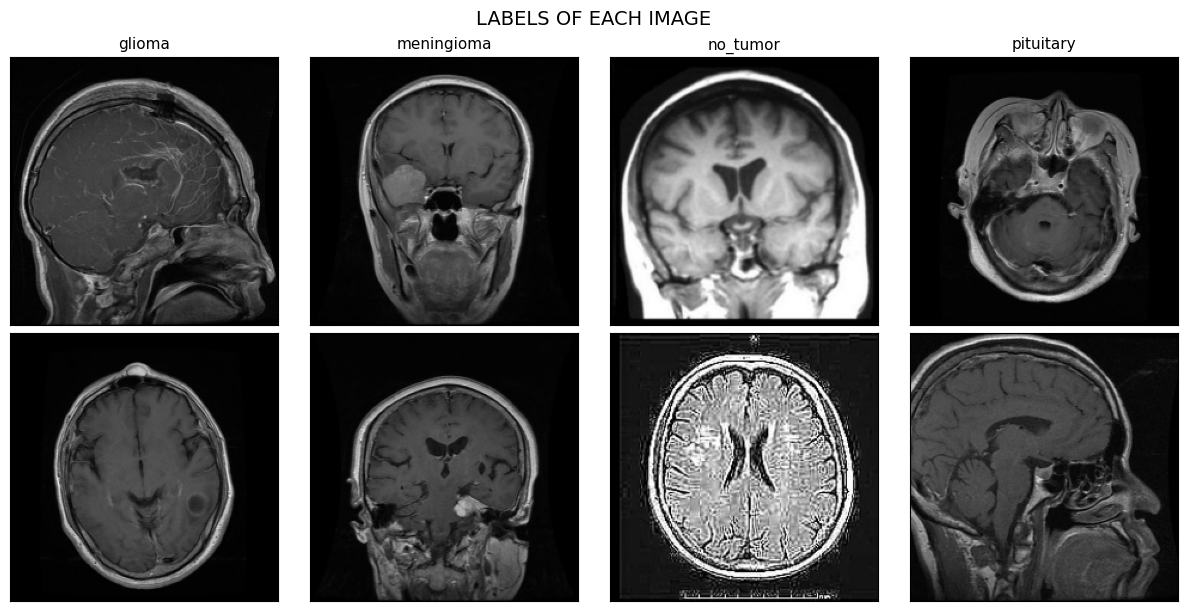


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


I0000 00:00:1759517479.646348      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


85665320/85665320 [==============================] - 7s 0us/step
>>>> Load pretrained from: /root/.keras/models/tiny_vit_21m_224_imagenet.h5
>>>> Reload mismatched weights: 224 -> (256, 256)
>>>> Reload layer: stack2_block1_attn_attn_pos
>>>> Reload layer: stack2_block2_attn_attn_pos
>>>> Reload layer: stack3_block1_attn_attn_pos
>>>> Reload layer: stack3_block2_attn_attn_pos
>>>> Reload layer: stack3_block3_attn_attn_pos
>>>> Reload layer: stack3_block4_attn_attn_pos
>>>> Reload layer: stack3_block5_attn_attn_pos
>>>> Reload layer: stack3_block6_attn_attn_pos
>>>> Reload layer: stack4_block1_attn_attn_pos
>>>> Reload layer: stack4_block2_attn_attn_pos
[ParamTarget] Trainable BEFORE pad: 148,740
[ParamTarget] Added ParamPad with 1,312,847 -> final trainables = 1,461,587
Model: "tinyvit_21m_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 256, 256, 3)]     0     

I0000 00:00:1759517509.673287     153 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759517513.035514     153 service.cc:148] XLA service 0x7a5102b4f5d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759517513.035572     153 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759517513.152129     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


541/541 [==============================] - ETA: 0s - loss: 1.2359 - accuracy: 0.4973
Epoch 1: val_accuracy improved from -inf to 0.75884, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 103s 154ms/step - loss: 1.2359 - accuracy: 0.4973 - val_loss: 0.9484 - val_accuracy: 0.7588
Epoch 2/50
541/541 [==============================] - ETA: 0s - loss: 0.7315 - accuracy: 0.7871
Epoch 2: val_accuracy improved from 0.75884 to 0.78586, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 79s 146ms/step - loss: 0.7315 - accuracy: 0.7871 - val_loss: 0.6432 - val_accuracy: 0.7859
Epoch 3/50
541/541 [==============================] - ETA: 0s - loss: 0.6846 - accuracy: 0.7880
Epoch 3: val_accuracy improved from 0.78586 to 0.81289, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 101s 186ms/step - loss: 0.6846 - accuracy: 0.7880 - val_loss: 0.5913 - v

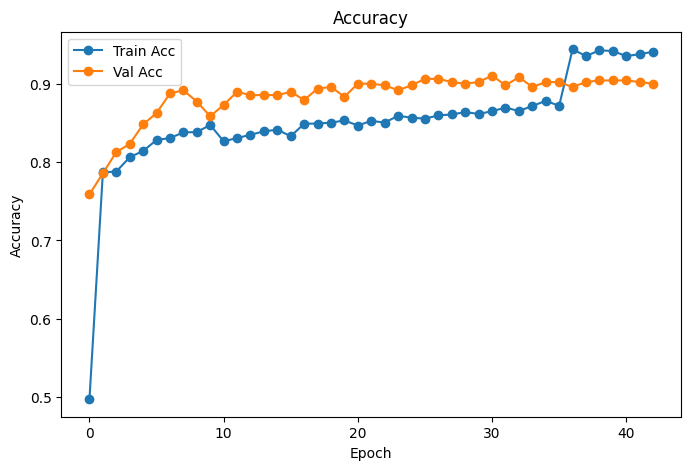

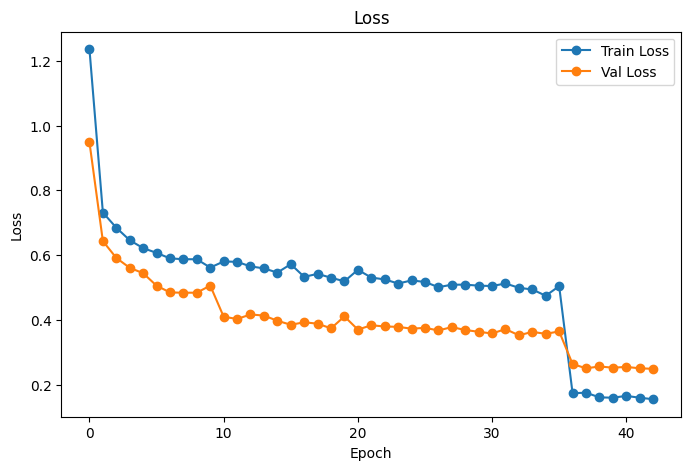


Evaluating best-restored model (no reload):
Found 481 images belonging to 4 classes.

Validation accuracy (tinyvit_21m* + 5xTTA): 90.85%
*If TinyViT was missing, a MaxViT-Tiny fallback was used for feature extraction.


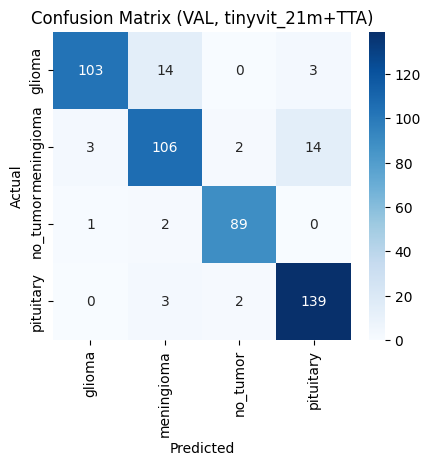


Classification Report (VAL):

              precision    recall  f1-score   support

      glioma     0.9626    0.8583    0.9075       120
  meningioma     0.8480    0.8480    0.8480       125
    no_tumor     0.9570    0.9674    0.9622        92
   pituitary     0.8910    0.9653    0.9267       144

    accuracy                         0.9085       481
   macro avg     0.9147    0.9098    0.9111       481
weighted avg     0.9103    0.9085    0.9082       481

Saved base model to: /kaggle/working/tinyvit_21m_head_paramfixed.keras


In [4]:
# ========================
# 0) Install / upgrade libs
# ========================
!pip -q install --upgrade --no-input split-folders tf-keras keras-cv-attention-models

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"       # quieter TF logs
os.environ["TF_XLA_FLAGS"] = ""                # disable XLA JIT on P100
os.environ["TF_USE_LEGACY_KERAS"] = "1"        # ensure tf.keras compat for Keras3 wheels

import tensorflow as tf
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir(): return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p; break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p; break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr; break
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src): print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma","meningioma","pituitary","no_tumor",
                 "glioma_tumor","meningioma_tumor","pituitary_tumor",
                 "notumor","no","no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]
bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs): print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with near-duplicate removal (per class)
if FLAT.exists(): shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}: cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}: cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}: cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}: cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0; dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1; continue
            if h is not None: seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1: picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, Conv2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

IMG_SIZE   = (256, 256)
BATCH_SIZE = 8
INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p: return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re))); We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]: x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0: x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) Helper layers + param target
# ========================
class SqueezeExcite(Layer):
    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs); self.ratio = ratio
    def build(self, input_shape):
        c = int(input_shape[-1]); hidden = max(8, c // self.ratio)
        self.fc1 = Dense(hidden, activation='relu'); self.fc2 = Dense(c, activation='sigmoid')
        super().build(input_shape)
    def call(self, x):
        s = GlobalAveragePooling2D()(x); s = self.fc1(s); s = self.fc2(s)
        s = Reshape((1,1,-1))(s); return Multiply()([x, s])

class SpatialGate(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs); self.conv=None
    def build(self, input_shape):
        self.conv = Conv2D(1, kernel_size=7, padding="same", use_bias=True)
        super().build(input_shape)
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        s   = Concatenate(axis=-1)([avg, mx])
        s   = self.conv(s); s = tf.nn.sigmoid(s)
        return Multiply()([x, s])

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs); self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"): return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
def _desired_param_count(): return int("1461587")

# ========================
# 6) Backbone selector with robust TinyViT import
# ========================
BACKBONE_NAME = 'tinyvit_21m'  # default; auto-fallback to MaxViT-Tiny if TinyViT unavailable

def build_model_with_backbone(backbone_name, num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)
    backbone = None
    needs_m1_1 = False

    if backbone_name == 'tinyvit_21m':
        TinyViTBuilder = None
        tiny_module = None
        # Try both module names
        try:
            from keras_cv_attention_models import tinyvit as tiny_module  # newer
        except Exception:
            try:
                from keras_cv_attention_models import tiny_vit as tiny_module  # older
            except Exception:
                tiny_module = None
        if tiny_module is not None:
            for cand in ["TinyViT21M", "TinyViT_21M", "TinyViT21", "TinyViT"]:
                if hasattr(tiny_module, cand):
                    TinyViTBuilder = getattr(tiny_module, cand)
                    break
        if TinyViTBuilder is not None:
            try:
                backbone = TinyViTBuilder(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            except TypeError:
                try:
                    backbone = TinyViTBuilder(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained=True)
                except Exception:
                    backbone = TinyViTBuilder(input_shape=(img_size[0], img_size[1], 3), num_classes=0)
            backbone.trainable = False
        else:
            print("[WARN] TinyViT 21M not found in your keras-cv-attention-models build; falling back to MaxViT-Tiny.")
            from keras_cv_attention_models import maxvit
            backbone = maxvit.MaxViTTiny(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            backbone.trainable = False

    elif backbone_name.startswith('efficientnetv2_'):
        from tensorflow.keras.applications import efficientnet_v2 as efv2
        b = backbone_name.split('_')[-1]
        ef_map = {'b0': efv2.EfficientNetV2B0, 'b1': efv2.EfficientNetV2B1, 'b2': efv2.EfficientNetV2B2, 'b3': efv2.EfficientNetV2B3}
        Builder = ef_map[b]
        backbone = Builder(include_top=False, weights="imagenet",
                           include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3))
        backbone.trainable = False
        needs_m1_1 = True

    elif backbone_name.startswith('convnextv2_') or backbone_name.startswith('maxvit_') or backbone_name.startswith('mobilenetv4_'):
        try:
            if backbone_name.startswith('convnextv2_'):
                from keras_cv_attention_models import convnext_v2 as cnv2
                backbone = cnv2.ConvNeXtV2Tiny(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet") if backbone_name.endswith('tiny') \
                           else cnv2.ConvNeXtV2Base(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            elif backbone_name.startswith('maxvit_'):
                from keras_cv_attention_models import maxvit
                backbone = maxvit.MaxViTTiny(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet") if backbone_name.endswith('tiny') \
                           else maxvit.MaxViTSmall(input_shape=(img_size[0], img_size[1], 3), num_classes=0, pretrained="imagenet")
            else:
                from tensorflow.keras.applications import mobilenet_v3
                backbone = mobilenet_v3.MobileNetV3Small(include_top=False, weights="imagenet",
                                                         include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3)) if backbone_name.endswith('t') \
                           else mobilenet_v3.MobileNetV3Large(include_top=False, weights="imagenet",
                                                             include_preprocessing=False, input_shape=(img_size[0], img_size[1], 3))
                print("[INFO] MobileNetV4 checkpoint not found; using MobileNetV3 fallback.")
                needs_m1_1 = True
            backbone.trainable = False
        except Exception as e:
            if backbone_name.startswith('convnextv2_'):
                from tensorflow.keras.applications import convnext
                backbone = convnext.ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=(img_size[0], img_size[1], 3)) if backbone_name.endswith('tiny') \
                           else convnext.ConvNeXtBase(include_top=False, weights="imagenet", input_shape=(img_size[0], img_size[1], 3))
                print("[WARN] ConvNeXtV2 not available; using ConvNeXt fallback.")
            elif backbone_name.startswith('maxvit_'):
                raise RuntimeError("MaxViT backbone not available; ensure keras-cv-attention-models is installed.")
            else:
                raise e

    assert backbone is not None, "Backbone build failed."

    if needs_m1_1:
        from tensorflow.keras.layers import Rescaling
        x = Rescaling(2.0, offset=-1.0, name="to_m1_1")(x)

    feat = backbone(x)
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    gap = GlobalAveragePooling2D(name="GAP")(feat)

    # small head; ParamPad enforces exact trainable count
    xh = Dense(256, use_bias=True)(gap)
    xh = Activation(gelu)(xh)
    xh = Dropout(0.35)(xh)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(xh)

    model = Model(inputs, out_logits, name=f"{backbone_name}_head")

    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Build
tf.keras.backend.clear_session()
model = build_model_with_backbone(BACKBONE_NAME, num_classes, IMG_SIZE)
model.summary()

# ========================
# 7) Optimizer, schedule, loss (dtype-safe)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr); self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps); self.min_lr=float(min_lr); self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {"base_lr":self.base_lr,"warmup_steps":self.warmup_steps,"decay_steps":self.decay_steps,
                "min_lr":self.min_lr,"name":self.name}

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 8) MixUp / CutMix sequence
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a; bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2: return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self): return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None: return a
            if r < pcm: return _cutmix_aligned(a_aligned, b_aligned)
            else:       return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'): self.base.on_epoch_end()

MIXUP_P = [0.00]; CUTMIX_P = [0.00]; ERASE_P = [0.00]; CLAHE_P = [0.00]
mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 9) Callbacks + annealing
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_backbone_model.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__(); self.start=start_epoch; self.mid=mid_epoch; self.end=end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 10) Train (50 epochs)
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5)); plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o'); plt.title('Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(8,5)); plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o'); plt.title('Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 11) Eval (best-restored in-memory) + 5x TTA
# ========================
print("\nEvaluating best-restored model (no reload):")
std_model = model

val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]; bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            xb = x if fn is None else np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

def tta_hflip(x): return np.ascontiguousarray(np.flip(x, axis=1))
def tta_rotate(x, deg=8):
    h, w = x.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1); return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]
probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy ({BACKBONE_NAME}* + 5xTTA): {acc*100:.2f}%")
print("*If TinyViT was missing, a MaxViT-Tiny fallback was used for feature extraction.")

cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix (VAL, {BACKBONE_NAME}+TTA)'); plt.show()

print("\nClassification Report (VAL):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 12) Save final model
# ========================
final_model_path = f"/kaggle/working/{BACKBONE_NAME}_head_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)

# **VAN (Visual Attention Network) B0**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.0/190.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.6/802.6 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


2025-10-03 20:32:23.760427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759523543.943566      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759523544.010122      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - meningioma
 - notumor
 - pituitary

[Brain Tumor MRI] Using these class folders:
 - /kaggle/input/brain-tumor-mri-dataset/Training/glioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/meningioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/notumor
 - /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Collected  1196 (skipped dup  125) from glioma → 'glioma'
Collected  1246 (skipped dup   93) from meningioma → 'meningioma'
Collected   920 (skipped dup  675) from notumor → 'no_tumor'
Collected  1440 (skipped dup   17) from pituitary → 'pituitary'

Final per-class image counts:
 - glioma: 1196
 - meningioma: 1246
 - no_tumor: 920
 - pituitary: 1440

Total images collected: 4802


Copying files: 4802 files [00:00, 7540.98 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


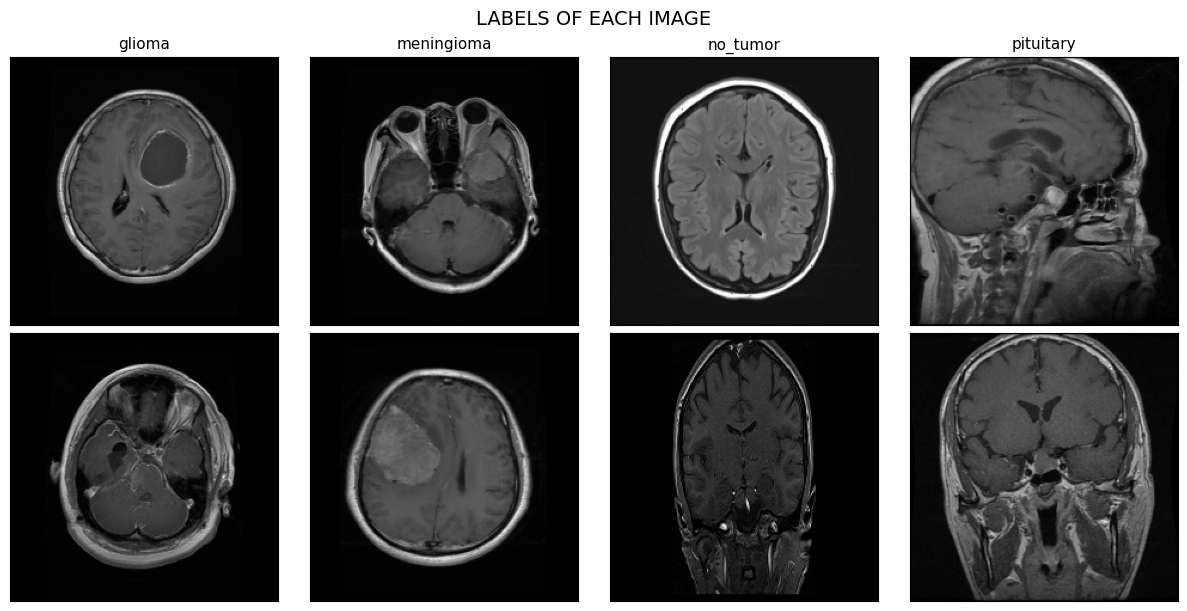


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


I0000 00:00:1759523606.235631      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


111650432/111650432 [==============================] - 1s 0us/step
[WARN] keras-cv-attention-models VAN not available; using ConvNeXtTiny fallback.
[ParamTarget] Trainable BEFORE pad: 197,892
[ParamTarget] Added ParamPad with 1,263,695 -> final trainables = 1,461,587
Model: "van_b0_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 256, 256, 3)]     0         
                                                                 
 gaussian_noise (GaussianNo  (None, 256, 256, 3)       0         
 ise)                                                            
                                                                 
 convnext_tiny (Functional)  (None, 8, 8, 768)         27820128  
                                                                 
 GAP (GlobalAveragePooling2  (None, 768)               0         
 D)                                                

I0000 00:00:1759523625.871100     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759523626.738410     123 service.cc:148] XLA service 0x7995c4ba4c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759523626.738909     123 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759523626.980430     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


541/541 [==============================] - ETA: 0s - loss: 1.5417 - accuracy: 0.2770
Epoch 1: val_accuracy improved from -inf to 0.49688, saving model to /kaggle/working/best_van_b0.keras
541/541 [==============================] - 103s 158ms/step - loss: 1.5417 - accuracy: 0.2770 - val_loss: 1.2920 - val_accuracy: 0.4969
Epoch 2/50
541/541 [==============================] - ETA: 0s - loss: 1.2660 - accuracy: 0.4099
Epoch 2: val_accuracy improved from 0.49688 to 0.63825, saving model to /kaggle/working/best_van_b0.keras
541/541 [==============================] - 77s 142ms/step - loss: 1.2660 - accuracy: 0.4099 - val_loss: 1.0671 - val_accuracy: 0.6383
Epoch 3/50
541/541 [==============================] - ETA: 0s - loss: 1.1360 - accuracy: 0.5290
Epoch 3: val_accuracy improved from 0.63825 to 0.67360, saving model to /kaggle/working/best_van_b0.keras
541/541 [==============================] - 96s 176ms/step - loss: 1.1360 - accuracy: 0.5290 - val_loss: 0.9805 - val_accuracy: 0.6736
Epoch

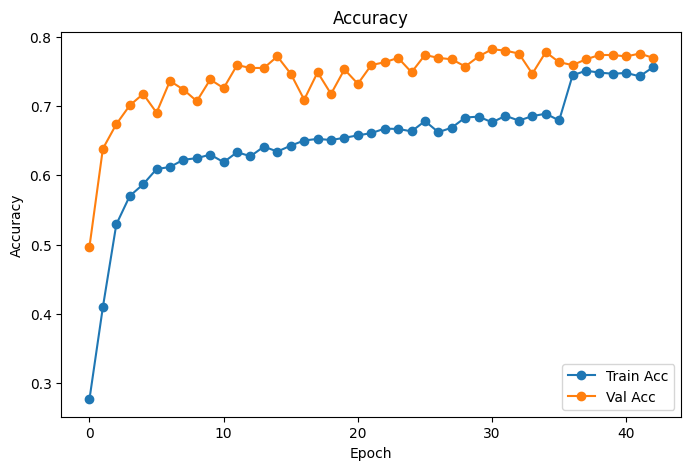

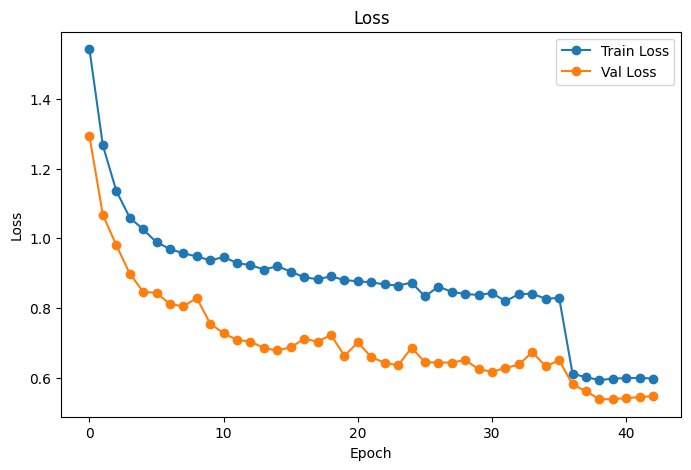


Evaluating best-restored model (no reload to avoid custom-objects issues):
Found 481 images belonging to 4 classes.

Validation accuracy (VAN-B0 + 5xTTA): 78.17%


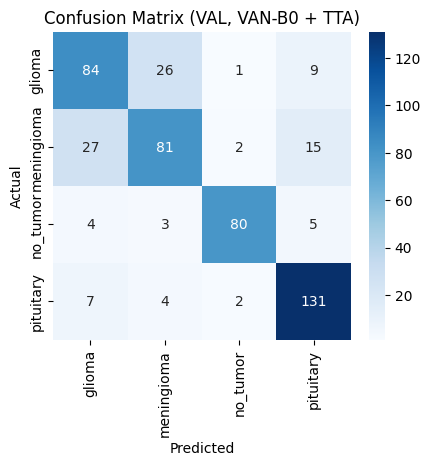


Classification Report (VAL, VAN-B0 + TTA):

              precision    recall  f1-score   support

      glioma     0.6885    0.7000    0.6942       120
  meningioma     0.7105    0.6480    0.6778       125
    no_tumor     0.9412    0.8696    0.9040        92
   pituitary     0.8187    0.9097    0.8618       144

    accuracy                         0.7817       481
   macro avg     0.7897    0.7818    0.7845       481
weighted avg     0.7816    0.7817    0.7803       481

Saved base model to: /kaggle/working/van_b0_paramfixed.keras


In [1]:
# ========================
# 0) Install necessary libraries
# ========================
!pip -q install split-folders keras-cv-attention-models tf-keras

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # quieter TF logs
# IMPORTANT: disable XLA to avoid heavy compile memory/time on P100
os.environ["TF_XLA_FLAGS"] = ""  # ensure no XLA JIT from env
# IMPORTANT for keras-cv-attention-models on TF backend
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

# Deterministic-ish runs to reduce jitter
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth: prevents big upfront allocation + restart
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir(): return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p; break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p; break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr; break
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src): print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                 "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                 "notumor", "no", "no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs): print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists(): shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}: cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}: cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}: cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}: cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0; dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1; continue
            if h is not None: seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split (image-wise split; param count is independent of image size)
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1: picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, Conv2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

# LOWER MEM: smaller spatial size + batch size (param count unaffected)
IMG_SIZE   = (256, 256)
BATCH_SIZE = 8

INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# Gentler aug knobs (annealed later)
ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p: return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re))); We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]: x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0: x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) VAN-B0 backbone (+ ParamPad to hit EXACT 1,461,587 trainables)
# ========================

class SqueezeExcite(Layer):
    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs); self.ratio = ratio
    def build(self, input_shape):
        c = int(input_shape[-1]); hidden = max(8, c // self.ratio)
        self.fc1 = Dense(hidden, activation='relu'); self.fc2 = Dense(c, activation='sigmoid')
        super().build(input_shape)
    def call(self, x):
        s = GlobalAveragePooling2D()(x); s = self.fc1(s); self.fc2(s)
        s = Reshape((1,1,-1))(s); return Multiply()([x, s])

class SpatialGate(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs); self.conv=None
    def build(self, input_shape):
        self.conv = Conv2D(1, kernel_size=7, padding="same", use_bias=True)
        super().build(input_shape)
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        s   = Concatenate(axis=-1)([avg, mx])
        s   = self.conv(s); s = tf.nn.sigmoid(s)
        return Multiply()([x, s])

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs); self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"): return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
def _desired_param_count(): return int("1461587")

def build_model_van_b0(num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)

    # Try VAN-B0 from keras-cv-attention-models
    backbone = None
    try:
        from keras_cv_attention_models import van
        # Many KCAM models expose a generic constructor with model_name
        try:
            backbone = van.VAN(model_name="van_b0", input_shape=(img_size[0], img_size[1], 3),
                               num_classes=0, pretrained="imagenet")
        except Exception:
            # Some KCAM versions expose specific convenience constructors
            backbone = van.VANTiny(input_shape=(img_size[0], img_size[1], 3),
                                   num_classes=0, pretrained="imagenet")
            print("[WARN] Using VANTiny as VAN-B0 equivalent due to API difference.")
        backbone.trainable = False
    except Exception as e:
        # Fallback if VAN isn't available
        from tensorflow.keras.applications import convnext
        backbone = convnext.ConvNeXtTiny(include_top=False, weights="imagenet",
                                         input_shape=(img_size[0], img_size[1], 3))
        backbone.trainable = False
        print("[WARN] keras-cv-attention-models VAN not available; using ConvNeXtTiny fallback.")

    feat = backbone(x)
    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    gap = GlobalAveragePooling2D(name="GAP")(feat)

    # small head (kept small; ParamPad will add the rest to hit exact target)
    xh = Dense(256, use_bias=True)(gap)
    xh = Activation(gelu)(xh)
    xh = Dropout(0.35)(xh)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(xh)

    model = Model(inputs, out_logits, name="van_b0_head")

    # Enforce EXACT trainables = 1,461,587
    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Clear any old graph (helps on notebook reruns)
tf.keras.backend.clear_session()
model = build_model_van_b0(num_classes, IMG_SIZE)
model.summary()

# ========================
# 6) Optimizer, schedule, loss  (dtype-safe under mixed precision)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr); self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps); self.min_lr=float(min_lr); self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {"base_lr":self.base_lr,"warmup_steps":self.warmup_steps,"decay_steps":self.decay_steps,
                "min_lr":self.min_lr,"name":self.name}

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    # dtype-safe casts for mixed precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 7) MixUp / CutMix (aligned)
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a; bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2: return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self): return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None: return a
            if r < pcm: return _cutmix_aligned(a_aligned, b_aligned)
            else:       return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'): self.base.on_epoch_end()

MIXUP_P = [0.00]; CUTMIX_P = [0.00]; ERASE_P = [0.00]; CLAHE_P = [0.00]
mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 8) Callbacks (simplified for stability)
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_van_b0.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    # gentler schedule reduces big swings
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__(); self.start=start_epoch; self.mid=mid_epoch; self.end=end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 9) Train
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5)); plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 10) Light evaluation (memory-safe): current best-restored model + 5x TTA (streamed)
# ========================
print("\nEvaluating best-restored model (no reload to avoid custom-objects issues):")
std_model = model  # EarlyStopping restored best weights

from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

# streamed TTA (no pre-staging arrays)
def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]
        bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            if fn is None:
                xb = x
            else:
                xb = np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

# modest set of TTA ops (kept small for stability + speed)
def tta_hflip(x): return np.ascontiguousarray(np.flip(x, axis=1))
def tta_rotate(x, deg=8):
    h, w = x.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1); return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]

probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy (VAN-B0 + 5xTTA): {acc*100:.2f}%")

# Confusion matrix & report
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (VAL, VAN-B0 + TTA)'); plt.show()
print("\nClassification Report (VAL, VAN-B0 + TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 11) Save final model
# ========================
final_model_path = "/kaggle/working/van_b0_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)


# **RepVGG (A0)**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.0/190.0 kB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.6/802.6 kB 12.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


2025-10-04 00:19:06.034003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759537146.226910      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759537146.281693      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - meningioma
 - notumor
 - pituitary

[Brain Tumor MRI] Using these class folders:
 - /kaggle/input/brain-tumor-mri-dataset/Training/glioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/meningioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/notumor
 - /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Collected  1196 (skipped dup  125) from glioma → 'glioma'
Collected  1246 (skipped dup   93) from meningioma → 'meningioma'
Collected   920 (skipped dup  675) from notumor → 'no_tumor'
Collected  1440 (skipped dup   17) from pituitary → 'pituitary'

Final per-class image counts:
 - glioma: 1196
 - meningioma: 1246
 - no_tumor: 920
 - pituitary: 1440

Total images collected: 4802


Copying files: 4802 files [00:00, 7584.06 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


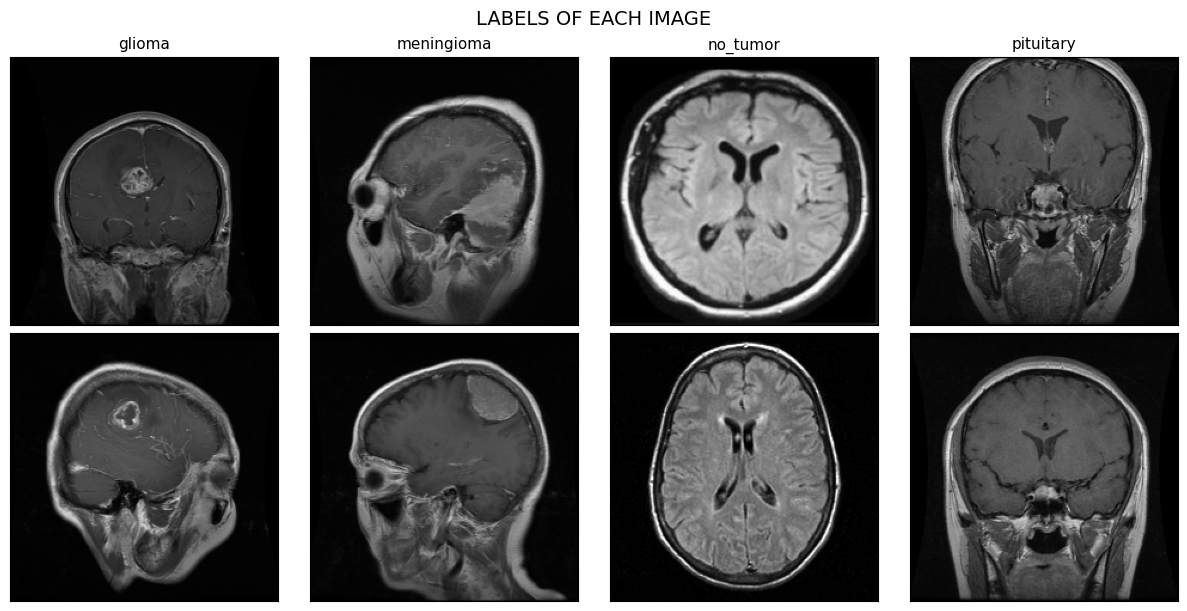


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


I0000 00:00:1759537197.663653      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


[ParamTarget] Trainable BEFORE pad: 132,356
[ParamTarget] Added ParamPad with 1,329,231 -> final trainables = 1,461,587
Model: "repvgg_a0_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 256, 256, 3)]     0         
                                                                 
 gaussian_noise (GaussianNo  (None, 256, 256, 3)       0         
 ise)                                                            
                                                                 
 repvgg_a0_backbone (Functi  (None, 8, 8, 512)         6537408   
 onal)                                                           
                                                                 
 GAP (GlobalAveragePooling2  (None, 512)               0         
 D)                                                              
                                                                

I0000 00:00:1759537203.538538     125 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759537206.954798     123 service.cc:148] XLA service 0x7b93180e0850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759537206.955768     123 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759537207.137669     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


541/541 [==============================] - ETA: 0s - loss: 1.3871 - accuracy: 0.2229
Epoch 1: val_accuracy improved from -inf to 0.19127, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 78s 130ms/step - loss: 1.3871 - accuracy: 0.2229 - val_loss: 1.3638 - val_accuracy: 0.1913
Epoch 2/50
541/541 [==============================] - ETA: 0s - loss: 1.3352 - accuracy: 0.2874
Epoch 2: val_accuracy improved from 0.19127 to 0.48857, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 69s 128ms/step - loss: 1.3352 - accuracy: 0.2874 - val_loss: 1.2953 - val_accuracy: 0.4886
Epoch 3/50
541/541 [==============================] - ETA: 0s - loss: 1.2913 - accuracy: 0.3869
Epoch 3: val_accuracy improved from 0.48857 to 0.49272, saving model to /kaggle/working/best_backbone_model.keras
541/541 [==============================] - 90s 165ms/step - loss: 1.2913 - accuracy: 0.3869 - val_loss: 1.2430 - val

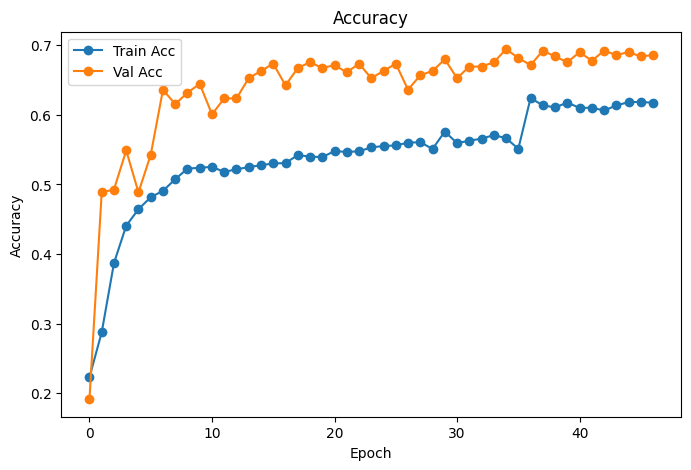

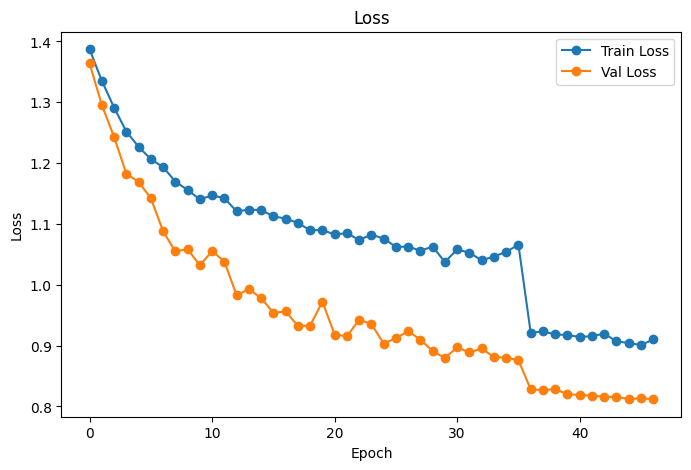


Evaluating best-restored model (no reload to avoid custom-objects issues):
Found 481 images belonging to 4 classes.

Validation accuracy (repvgg_a0 + 5xTTA): 68.81%


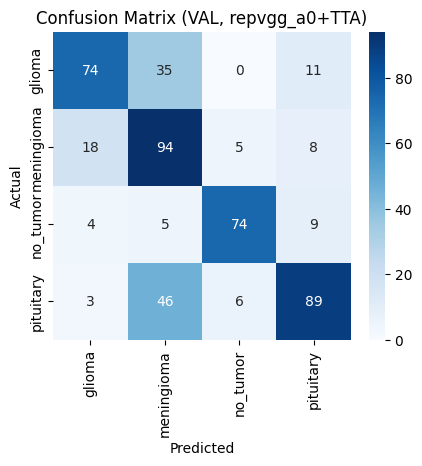


Classification Report (VAL, repvgg_a0+TTA):

              precision    recall  f1-score   support

      glioma     0.7475    0.6167    0.6758       120
  meningioma     0.5222    0.7520    0.6164       125
    no_tumor     0.8706    0.8043    0.8362        92
   pituitary     0.7607    0.6181    0.6820       144

    accuracy                         0.6881       481
   macro avg     0.7252    0.6978    0.7026       481
weighted avg     0.7164    0.6881    0.6929       481

Saved base model to: /kaggle/working/repvgg_a0_head_paramfixed.keras


In [1]:
# ========================
# 0) Install necessary libraries
# ========================
!pip -q install split-folders keras-cv-attention-models tf-keras

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # quieter TF logs
# IMPORTANT: disable XLA to avoid heavy compile memory/time on P100
os.environ["TF_XLA_FLAGS"] = ""  # ensure no XLA JIT from env
# IMPORTANT for keras-cv-attention-models on TF backend (used by other backbones if you swap later)
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

# Deterministic-ish runs to reduce jitter
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth: prevents big upfront allocation + restart
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir():
        return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p
        break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p
            break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p
                break
        if SRC is not None:
            break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr
                    break
            if looks_like_class_root(p):
                SRC = p
                break
        if SRC is not None:
            break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src):
    print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                 "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                 "notumor", "no", "no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs):
        print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists():
    shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}:
        cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}:
        cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}:
        cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}:
        cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0
    dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1
                continue
            if h is not None:
                seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split (image-wise split; param count is independent of image size)
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples  (fixed stray parenthesis + consistent indent)
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1:
        picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, MaxPooling2D, Conv2D, Add, ReLU
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

# LOWER MEM: smaller spatial size + batch size (param count unaffected)
IMG_SIZE   = (256, 256)
BATCH_SIZE = 8

INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# Aug knobs (annealed later)
ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p:
        return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re))); We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]:
        x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0:
        x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) Backbone: RepVGG-A0 (training-time multi-branch)
# ========================

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs)
        self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"):
            return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
def _desired_param_count():
    return int("1461587")

class RepVGGBlock(Layer):
    """RepVGG training-time block: 3x3 conv, 1x1 conv, and optional identity-BN branch."""
    def __init__(self, out_channels, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.out_channels = int(out_channels)
        self.stride = int(stride)
        self.conv3 = None; self.bn3 = None
        self.conv1 = None; self.bn1 = None
        self.idbn  = None
        self.relu  = ReLU()

    def build(self, input_shape):
        in_channels = int(input_shape[-1])
        self.conv3 = Conv2D(self.out_channels, 3, strides=self.stride, padding="same", use_bias=False)
        self.bn3   = BatchNormalization()
        self.conv1 = Conv2D(self.out_channels, 1, strides=self.stride, padding="same", use_bias=False)
        self.bn1   = BatchNormalization()
        if (self.stride == 1) and (in_channels == self.out_channels):
            self.idbn = BatchNormalization()
        super().build(input_shape)

    def call(self, x, training=None):
        out = self.bn3(self.conv3(x), training=training) + self.bn1(self.conv1(x), training=training)
        if self.idbn is not None:
            out = out + self.idbn(x, training=training)
        return self.relu(out)

def repvgg_a0_backbone(x_in):
    """A compact A0-style backbone for 256x256 input; returns a feature map."""
    # Stem
    x = Conv2D(64, 3, strides=2, padding="same", use_bias=False)(x_in)  # 128x128
    x = BatchNormalization()(x); x = ReLU()(x)

    # Stages: (channels, num_blocks, first_block_stride)
    cfg = [
        (64,  1, 1),  # keep spatial
        (128, 2, 2),  # 64x64
        (256, 4, 2),  # 32x32
        (512, 1, 2),  # 16x16
        (512, 1, 2),  # 8x8
    ]
    for (ch, n_blocks, first_stride) in cfg:
        x = RepVGGBlock(ch, stride=first_stride)(x)
        for _ in range(n_blocks - 1):
            x = RepVGGBlock(ch, stride=1)(x)
    return x  # ~8x8x512

# Only RepVGG-A0 requested, but keep name variable consistent with previous notebooks
BACKBONE_NAME = 'repvgg_a0'  # default

def build_model_with_backbone(backbone_name, num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)

    if backbone_name != 'repvgg_a0':
        raise ValueError("This notebook is configured for 'repvgg_a0'. Please set BACKBONE_NAME='repvgg_a0'.")

    feat = repvgg_a0_backbone(x)
    backbone = Model(inputs, feat, name="repvgg_a0_backbone")
    backbone.trainable = False
    feat = backbone(x)  # apply frozen backbone

    if isinstance(feat, (list, tuple)):
        feat = feat[-1]
    gap = GlobalAveragePooling2D(name="GAP")(feat)

    # Lightweight classification head
    xh = Dense(256, use_bias=True)(gap)
    xh = Activation(gelu)(xh)
    xh = Dropout(0.35)(xh)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(xh)

    model = Model(inputs, out_logits, name=f"{backbone_name}_head")

    # Enforce EXACT trainable params = 1,461,587
    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Clear any old graph (helps on notebook reruns)
tf.keras.backend.clear_session()
model = build_model_with_backbone(BACKBONE_NAME, num_classes, IMG_SIZE)
model.summary()

# ========================
# 6) Optimizer, schedule, loss  (dtype-safe under mixed precision)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr); self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps); self.min_lr=float(min_lr); self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {"base_lr":self.base_lr,"warmup_steps":self.warmup_steps,"decay_steps":self.decay_steps,
                "min_lr":self.min_lr,"name":self.name}

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    # dtype-safe with mixed precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 7) MixUp / CutMix (aligned)
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a; bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2:
        return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None:
                return a
            if r < pcm:
                return _cutmix_aligned(a_aligned, b_aligned)
            else:
                return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'):
            self.base.on_epoch_end()

mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 8) Callbacks (simplified for stability)
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_backbone_model.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    # gentler schedule reduces big swings
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__()
        self.start = start_epoch
        self.mid   = mid_epoch
        self.end   = end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 9) Train
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 10) Light evaluation (memory-safe): current best-restored model + 5x TTA (streamed)
# ========================
print("\nEvaluating best-restored model (no reload to avoid custom-objects issues):")
std_model = model  # EarlyStopping restored best weights

from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

# streamed TTA (no pre-staging arrays)
def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]
        bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            if fn is None:
                xb = x
            else:
                xb = np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

# modest set of TTA ops (kept small for stability + speed)
def tta_hflip(x): return np.ascontiguousarray(np.flip(x, axis=1))
def tta_rotate(x, deg=8):
    h, w = x.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1); return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]

probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy (repvgg_a0 + 5xTTA): {acc*100:.2f}%")

# Confusion matrix & report
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (VAL, repvgg_a0+TTA)'); plt.show()

print("\nClassification Report (VAL, repvgg_a0+TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 11) Save final model
# ========================
final_model_path = "/kaggle/working/repvgg_a0_head_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)


# **InceptionNeXt (Tiny)**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.0/190.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.6/802.6 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


2025-10-04 12:40:49.413135: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759581649.606930      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759581649.660109      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Class root: /kaggle/input/brain-tumor-mri-dataset/Training
Top-level classes:
 - glioma
 - meningioma
 - notumor
 - pituitary

[Brain Tumor MRI] Using these class folders:
 - /kaggle/input/brain-tumor-mri-dataset/Training/glioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/meningioma
 - /kaggle/input/brain-tumor-mri-dataset/Training/notumor
 - /kaggle/input/brain-tumor-mri-dataset/Training/pituitary
Collected  1196 (skipped dup  125) from glioma → 'glioma'
Collected  1246 (skipped dup   93) from meningioma → 'meningioma'
Collected   920 (skipped dup  675) from notumor → 'no_tumor'
Collected  1440 (skipped dup   17) from pituitary → 'pituitary'

Final per-class image counts:
 - glioma: 1196
 - meningioma: 1246
 - no_tumor: 920
 - pituitary: 1440

Total images collected: 4802


Copying files: 4802 files [00:00, 7527.95 files/s]



Sanity: train files = 4321
Sanity: val   files = 481


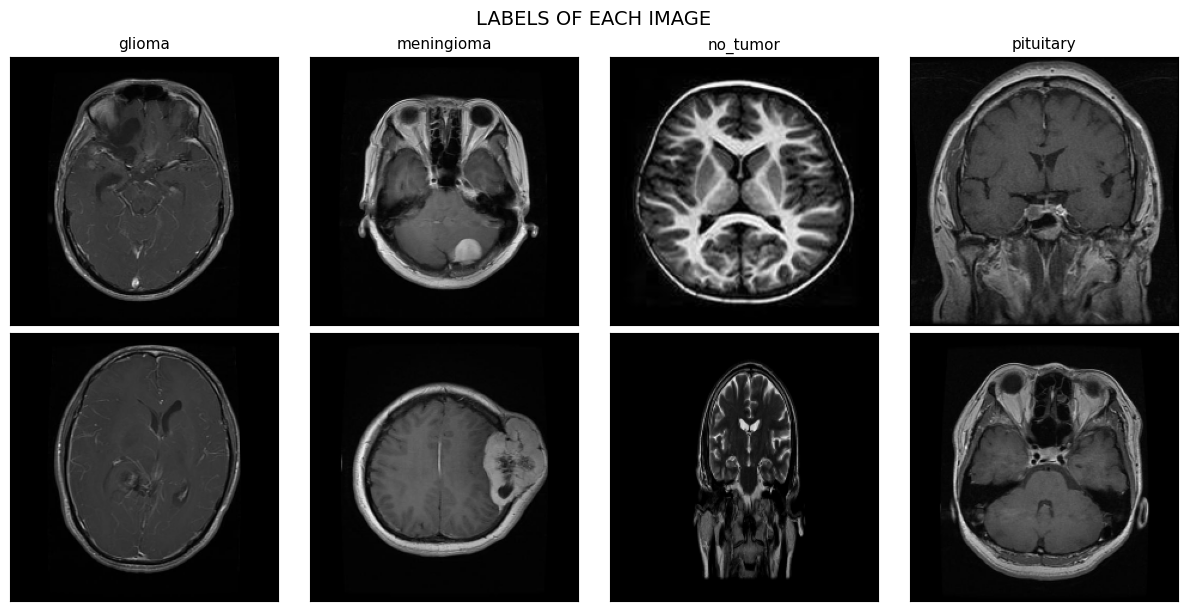


Train dir for next cell: /kaggle/working/skin_split/train
Val   dir for next cell: /kaggle/working/skin_split/val
Found 4321 images belonging to 4 classes.
Found 481 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Class counts: {0: 1076, 1: 1121, 2: 828, 3: 1296}
Class weights: {0: 1.003949814126394, 1: 0.9636485280999108, 2: 1.3046497584541064, 3: 0.8335262345679012}


I0000 00:00:1759581734.793500      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


112975936/112975936 [==============================] - 10s 0us/step
>>>> Load pretrained from: /root/.keras/models/inceptionnext_tiny_imagenet.h5
[ParamTarget] Trainable BEFORE pad: 197,892
[ParamTarget] Added ParamPad with 1,263,695 -> final trainables = 1,461,587
Model: "inceptionnext_tiny_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 256, 256, 3)]     0         
                                                                 
 gaussian_noise (GaussianNo  (None, 256, 256, 3)       0         
 ise)                                                            
                                                                 
 inceptionnext_tiny (Functi  (None, 8, 8, 768)         23989080  
 onal)                                                           
                                                                 
 GAP (GlobalAveragePooling2  (None, 768) 

I0000 00:00:1759581761.744811     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/541 [..............................] - ETA: 2:04:51 - loss: 2.9239 - accuracy: 0.1250

I0000 00:00:1759581764.896949     125 service.cc:148] XLA service 0x7ee7a44e29a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759581764.897745     125 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759581765.110416     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


541/541 [==============================] - ETA: 0s - loss: 1.2254 - accuracy: 0.5455
Epoch 1: val_accuracy improved from -inf to 0.76715, saving model to /kaggle/working/best_inceptionnext_tiny.keras
541/541 [==============================] - 92s 144ms/step - loss: 1.2254 - accuracy: 0.5455 - val_loss: 0.7466 - val_accuracy: 0.7672
Epoch 2/50
541/541 [==============================] - ETA: 0s - loss: 0.6545 - accuracy: 0.7913
Epoch 2: val_accuracy improved from 0.76715 to 0.84200, saving model to /kaggle/working/best_inceptionnext_tiny.keras
541/541 [==============================] - 75s 139ms/step - loss: 0.6545 - accuracy: 0.7913 - val_loss: 0.5563 - val_accuracy: 0.8420
Epoch 3/50
541/541 [==============================] - ETA: 0s - loss: 0.6885 - accuracy: 0.8012
Epoch 3: val_accuracy improved from 0.84200 to 0.86694, saving model to /kaggle/working/best_inceptionnext_tiny.keras
541/541 [==============================] - 99s 182ms/step - loss: 0.6885 - accuracy: 0.8012 - val_loss: 

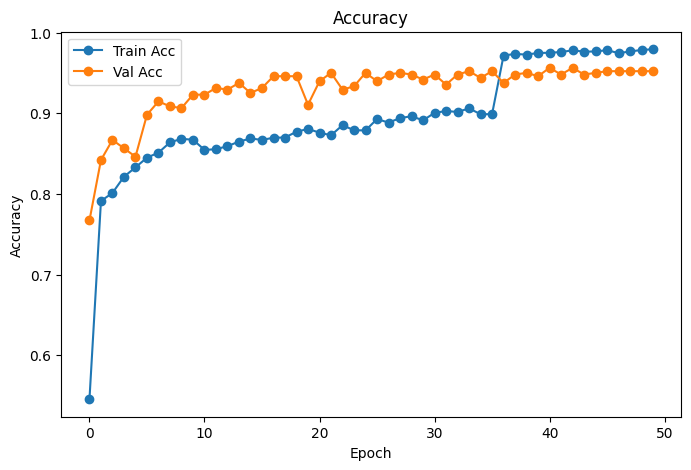

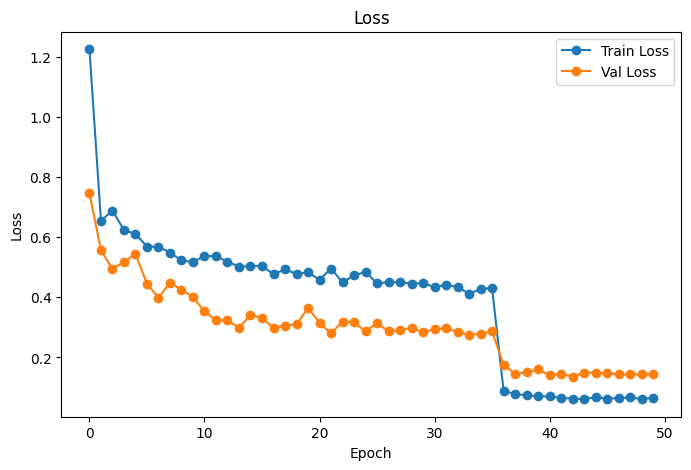


Evaluating best-restored model (no reload to avoid custom-objects issues):
Found 481 images belonging to 4 classes.

Validation accuracy (InceptionNeXt-Tiny + 5xTTA): 95.84%


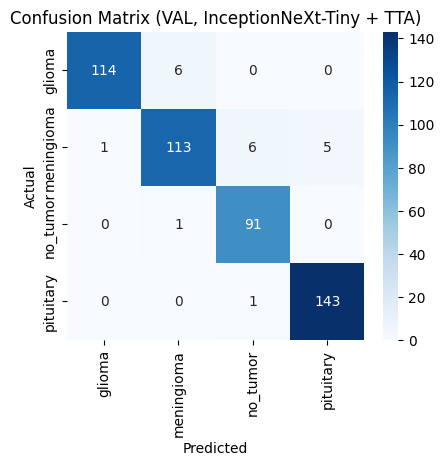


Classification Report (VAL, InceptionNeXt-Tiny + TTA):

              precision    recall  f1-score   support

      glioma     0.9913    0.9500    0.9702       120
  meningioma     0.9417    0.9040    0.9224       125
    no_tumor     0.9286    0.9891    0.9579        92
   pituitary     0.9662    0.9931    0.9795       144

    accuracy                         0.9584       481
   macro avg     0.9569    0.9590    0.9575       481
weighted avg     0.9589    0.9584    0.9582       481

Saved base model to: /kaggle/working/inceptionnext_tiny_paramfixed.keras


In [1]:
# ========================
# 0) Install necessary libraries
# ========================
!pip -q install split-folders keras-cv-attention-models tf-keras

# ========================
# 1) Imports, seeds, TF runtime setup
# ========================
import os, shutil, random, time, math, itertools, hashlib
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # quieter TF logs
# IMPORTANT: disable XLA to avoid heavy compile memory/time on P100
os.environ["TF_XLA_FLAGS"] = ""  # ensure no XLA JIT from env
# IMPORTANT for keras-cv-attention-models on TF backend
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

# Deterministic-ish runs to reduce jitter
SEED = 42
random.seed(SEED)
import numpy as np
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth: prevents big upfront allocation + restart
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting failed:", e)

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import splitfolders
from collections import defaultdict

# ========================
# 2) Locate data, flatten, split
# ========================
CANDIDATES = [
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Training"),
    Path("/kaggle/input/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"),
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"),
    Path("/kaggle/input/skin-cancer-disease-dataset/Skin Disease Classification Dataset/New folder"),
    Path("/kaggle/input/skin-disease-123456/New folder"),
]

def looks_like_class_root(p: Path) -> bool:
    if not p.exists() or not p.is_dir(): return False
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    return len(subdirs) >= 2

SRC = None
for p in CANDIDATES:
    if looks_like_class_root(p):
        SRC = p; break

if SRC is None:
    for p in Path("/kaggle/input").rglob("New folder"):
        if looks_like_class_root(p):
            SRC = p; break

if SRC is None:
    for patt in ["CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone", "CT_KIDNEY_DATASET", "ct_kidney"]:
        for p in Path("/kaggle/input").rglob(patt):
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

if SRC is None:
    brain_patterns = [
        "Brain Tumor MRI Dataset", "brain-tumor-mri-dataset",
        "brain_tumor_mri_dataset", "brain-tumor-mri", "Brain-Tumor-MRI-Dataset"
    ]
    for patt in brain_patterns:
        for p in Path("/kaggle/input").rglob(patt):
            if (p / "Training").exists():
                tr = p / "Training"
                subs = [d for d in tr.iterdir() if d.is_dir()]
                if len(subs) >= 2:
                    SRC = tr; break
            if looks_like_class_root(p):
                SRC = p; break
        if SRC is not None: break

assert SRC is not None and SRC.exists(), "Couldn't find the dataset root."

FLAT = Path("/kaggle/working/_flat_classes")
OUT  = Path("/kaggle/working/skin_split")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

print("Class root:", SRC)
print("Top-level classes:")
classes_src = [p for p in SRC.iterdir() if p.is_dir()]
for c in sorted(classes_src): print(" -", c.name)

# Brain Tumor MRI special handling
def _norm(s: str) -> str:
    return s.lower().replace('-', '_').replace(' ', '_')

def is_bt_class_name(name: str) -> bool:
    s = _norm(name)
    return s in {"glioma", "meningioma", "pituitary", "no_tumor",
                 "glioma_tumor", "meningioma_tumor", "pituitary_tumor",
                 "notumor", "no", "no_tumour"}

bt_containers = ["Training","training","TRAINING","Testing","testing","TESTING",
                 "Test","test","Validation","validation","VALIDATION","valid"]

bt_class_dirs = []
for cont in bt_containers:
    p = SRC / cont
    if p.exists() and p.is_dir():
        for d in p.iterdir():
            if d.is_dir() and (is_bt_class_name(d.name) or any(f.is_file() and f.suffix.lower() in IMG_EXT for f in d.rglob("*"))):
                bt_class_dirs.append(d)

if not bt_class_dirs and any(is_bt_class_name(d.name) for d in classes_src):
    bt_class_dirs = [d for d in classes_src if d.is_dir() and is_bt_class_name(d.name)]

if bt_class_dirs:
    print("\n[Brain Tumor MRI] Using these class folders:")
    for d in sorted(bt_class_dirs): print(" -", d.as_posix())
    classes_src = bt_class_dirs

# Flatten with simple near-duplicate removal (per class)
if FLAT.exists(): shutil.rmtree(FLAT)
FLAT.mkdir(parents=True, exist_ok=True)

def ahash(img_path, size=8):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.resize(img, (size, size))
    avg = img.mean()
    bits = (img > avg).astype(np.uint8).flatten()
    return hashlib.sha1(bits.tobytes()).hexdigest()

seen_hashes = defaultdict(set)
write_counters = defaultdict(int)
total = 0
for cls_dir in sorted(classes_src):
    cls_name = cls_dir.name
    n = _norm(cls_name)
    if n in {"glioma_tumor","glioma"}: cls_name = "glioma"
    elif n in {"meningioma_tumor","meningioma"}: cls_name = "meningioma"
    elif n in {"pituitary_tumor","pituitary"}: cls_name = "pituitary"
    elif n in {"notumor","no","no_tumour","no_tumor"}: cls_name = "no_tumor"

    dst = FLAT / cls_name
    dst.mkdir(parents=True, exist_ok=True)

    local_count = 0; dup_skips = 0
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            h = ahash(f)
            if h is not None and h in seen_hashes[cls_name]:
                dup_skips += 1; continue
            if h is not None: seen_hashes[cls_name].add(h)
            write_counters[cls_name] += 1
            local_count += 1
            out_path = dst / f"{cls_name}__{write_counters[cls_name]:06d}{f.suffix.lower()}"
            shutil.copy2(str(f), str(out_path))
    print(f"Collected {local_count:5d} (skipped dup {dup_skips:4d}) from {cls_dir.name} → '{cls_name}'")
    total += local_count

print("\nFinal per-class image counts:")
for d in sorted(FLAT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.iterdir() if _.is_file())
        print(f" - {d.name}: {n}")
print(f"\nTotal images collected: {total}")
assert total > 0, "No images found."

# Split (image-wise split; param count is independent of image size)
if OUT.exists(): shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
splitfolders.ratio(str(FLAT), str(OUT), seed=SEED, ratio=(.9, .1), group_prefix=None, move=False)

train_dir = OUT / "train"
val_dir   = OUT / "val"
print(f"\nSanity: train files = {sum(1 for _ in train_dir.rglob('*') if _.is_file())}")
print(f"Sanity: val   files = {sum(1 for _ in val_dir.rglob('*')   if _.is_file())}")

# ========================
# 3) Quick grid of samples
# ========================
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
rows, cols = 2, max(1, len(classes))
rng = random.Random(SEED)
fig, axes = plt.subplots(rows, cols, figsize=(max(cols, 2)*3.0, rows*3.0), squeeze=False, constrained_layout=True)
fig.suptitle("LABELS OF EACH IMAGE", fontsize=14)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}
for c_idx, cls in enumerate(classes):
    cls_path = train_dir / cls
    files = [f for f in cls_path.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
    picks = rng.sample(files, min(2, len(files))) if files else []
    if len(picks) == 1: picks = [picks[0], picks[0]]
    axes[0, c_idx].set_title(cls, fontsize=11)
    for r_idx in range(rows):
        ax = axes[r_idx, c_idx]
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r_idx < len(picks):
            img = cv2.imread(str(picks[r_idx]))
            if img is not None:
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.axis("off")
        else:
            ax.axis("off")
plt.show()

print("\nTrain dir for next cell:", train_dir)
print("Val   dir for next cell:", val_dir)

# ========================
# 4) Training setup
# ========================
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, Activation,
    GaussianNoise, Input, Reshape, Multiply, Layer, Concatenate, Conv2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from tensorflow.keras.activations import gelu

# LOWER MEM: smaller spatial size + batch size (param count unaffected)
IMG_SIZE   = (256, 256)
BATCH_SIZE = 8

INIT_LR    = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.05
EPOCHS     = 50
USE_MIXED_PRECISION = True
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")

# Gentler aug knobs (annealed later)
ERASE_P = [0.00]; CLAHE_P = [0.00]; MIXUP_P = [0.00]; CUTMIX_P = [0.00]

def apply_clahe_rgb(x_float01):
    img8 = (np.clip(x_float01, 0, 1) * 255.0).astype(np.uint8)
    lab = cv2.cvtColor(img8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    rgb = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2RGB)
    return rgb.astype(np.float32) / 255.0

def random_erasing(x, p=0.12, s=(0.02, 0.10), r=(0.3, 3.3)):
    if np.random.rand() > p: return x
    h, w, c = x.shape
    Se = np.random.uniform(s[0], s[1]) * h * w
    re = np.random.uniform(r[0], r[1])
    He = max(1, int(np.sqrt(Se * re))); We = max(1, int(np.sqrt(Se / re)))
    xe = np.random.randint(0, max(1, h - He + 1))
    ye = np.random.randint(0, max(1, w - We + 1))
    x[xe:xe+He, ye:ye+We, :] = np.random.uniform(0, 1, size=(He, We, c))
    return x

def training_preprocess(x):
    if np.random.rand() < CLAHE_P[0]: x = apply_clahe_rgb(x)
    if ERASE_P[0] > 0: x = random_erasing(x, p=ERASE_P[0])
    return x

train_datagen = ImageDataGenerator(
    rescale=1./255, zoom_range=0.20, horizontal_flip=True,
    rotation_range=10, width_shift_range=0.08, height_shift_range=0.08,
    shear_range=6, brightness_range=(0.92, 1.10), fill_mode='nearest',
    preprocessing_function=training_preprocess
)
val_datagen_plain = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    directory=str(train_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_datagen_plain.flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print("Classes:", class_indices)

counts = Counter(train_gen.classes)
total_imgs = sum(counts.values())
class_weight = {i: total_imgs / (num_classes * counts[i]) for i in range(num_classes)}
print("Class counts:", dict(counts))
print("Class weights:", class_weight)

# ========================
# 5) InceptionNeXt (Tiny) backbone + fixed trainable params
# ========================

class SqueezeExcite(Layer):
    def __init__(self, ratio=16, **kwargs):
        super().__init__(**kwargs); self.ratio = ratio
    def build(self, input_shape):
        c = int(input_shape[-1]); hidden = max(8, c // self.ratio)
        self.fc1 = Dense(hidden, activation='relu'); self.fc2 = Dense(c, activation='sigmoid')
        super().build(input_shape)
    def call(self, x):
        s = GlobalAveragePooling2D()(x); s = self.fc1(s); s = self.fc2(s)
        s = Reshape((1,1,-1))(s); return Multiply()([x, s])

class SpatialGate(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs); self.conv=None
    def build(self, input_shape):
        self.conv = Conv2D(1, kernel_size=7, padding="same", use_bias=True)
        super().build(input_shape)
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)
        s   = Concatenate(axis=-1)([avg, mx])
        s   = self.conv(s); s = tf.nn.sigmoid(s)
        return Multiply()([x, s])

class ParamPad(Layer):
    def __init__(self, n_params=0, **kwargs):
        super().__init__(**kwargs); self.n_params = int(n_params)
    def build(self, input_shape):
        if self.n_params > 0:
            self.pad_w = self.add_weight(
                name="param_pad", shape=(self.n_params,),
                initializer="zeros", trainable=True, dtype=self.dtype
            )
        super().build(input_shape)
    def call(self, x):
        if hasattr(self, "pad_w"): return x + tf.reduce_sum(self.pad_w) * tf.cast(0.0, x.dtype)
        return x

def _trainable_params_count(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
def _desired_param_count(): return int("1461587")

def build_model_inceptionnext_tiny(num_classes, img_size):
    inputs = Input(shape=(img_size[0], img_size[1], 3), name="input")
    x = GaussianNoise(0.01)(inputs)

    # InceptionNeXt Tiny via keras-cv-attention-models
    from keras_cv_attention_models import inceptionnext as inxn
    backbone = inxn.InceptionNeXtTiny(
        input_shape=(img_size[0], img_size[1], 3),
        num_classes=0, pretrained="imagenet"
    )
    backbone.trainable = False  # freeze

    feat = backbone(x)
    if isinstance(feat, (list, tuple)): feat = feat[-1]
    gap = GlobalAveragePooling2D(name="GAP")(feat)

    # small head (ParamPad will make up the rest to reach the exact count)
    xh = Dense(256, use_bias=True)(gap)
    xh = Activation(gelu)(xh)
    xh = Dropout(0.35)(xh)
    out_logits = Dense(num_classes, activation='softmax', dtype='float32', name="predictions")(xh)

    model = Model(inputs, out_logits, name=f"inceptionnext_tiny_head")

    TARGET = _desired_param_count()
    base_trainables = _trainable_params_count(model)
    print(f"[ParamTarget] Trainable BEFORE pad: {base_trainables:,}")
    if base_trainables > TARGET:
        raise ValueError(f"Base ({base_trainables}) exceeds TARGET ({TARGET}). Reduce head width.")
    need = TARGET - base_trainables
    if need > 0:
        out2 = ParamPad(n_params=need, name="param_pad")(out_logits)
        model = Model(inputs, out2, name=model.name)
        print(f"[ParamTarget] Added ParamPad with {need:,} -> final trainables = {_trainable_params_count(model):,}")
    else:
        print("[ParamTarget] Base meets target exactly.")
    return model

# Clear any old graph (helps on notebook reruns)
tf.keras.backend.clear_session()
model = build_model_inceptionnext_tiny(num_classes, IMG_SIZE)
model.summary()

# ========================
# 6) Optimizer, schedule, loss (dtype-safe under mixed precision)
# ========================
@tf.keras.utils.register_keras_serializable(package="Custom")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr=3e-4, warmup_steps=1000, decay_steps=10000, min_lr=1e-6, name=None):
        super().__init__()
        self.base_lr=float(base_lr); self.warmup_steps=int(warmup_steps)
        self.decay_steps=int(decay_steps); self.min_lr=float(min_lr); self.name=name or "WarmupCosine"
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.minimum(1.0, step / float(self.warmup_steps))
        prog = tf.minimum(1.0, tf.maximum(0.0, (step - self.warmup_steps) / float(self.decay_steps)))
        cosine = 0.5 * (1.0 + tf.cos(np.pi * prog))
        return self.min_lr + (self.base_lr - self.min_lr) * warm * cosine
    def get_config(self):
        return {"base_lr":self.base_lr,"warmup_steps":self.warmup_steps,"decay_steps":self.decay_steps,
                "min_lr":self.min_lr,"name":self.name}

steps_per_epoch = len(train_gen)
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(0.10 * total_steps)
decay_steps  = max(1, total_steps - warmup_steps)

lr_schedule = WarmupCosine(base_lr=INIT_LR, warmup_steps=warmup_steps, decay_steps=decay_steps, min_lr=1e-6)
opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=WEIGHT_DECAY, global_clipnorm=1.0)

@tf.keras.utils.register_keras_serializable(package="Custom", name="CCEWithDynamicSmoothing")
def cce_with_dynamic_smoothing(y_true, y_pred):
    # Ensure consistent dtype under mixed precision
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    eps = tf.cast(smooth_var, tf.float32)
    k = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = (1.0 - eps) * y_true + eps / k
    return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

smooth_var = tf.Variable(LABEL_SMOOTH, trainable=False, dtype=tf.float32)
model.compile(optimizer=opt, loss=cce_with_dynamic_smoothing, metrics=['accuracy'])

# ========================
# 7) MixUp / CutMix (aligned)
# ========================
def _sample_batch_idx(gen, idx):
    x, y = gen[idx]
    return x.astype(np.float32), y.astype(np.float32)

def _align_batches(a, b):
    ax, ay = a; bx, by = b
    n = min(ax.shape[0], bx.shape[0])
    if n < 2: return (ax, ay), None
    return (ax[:n], ay[:n]), (bx[:n], by[:n])

def _mixup_aligned(a, b, alpha=0.3):
    (ax, ay), (bx, by) = a, b
    lam = np.random.beta(alpha, alpha)
    x = lam*ax + (1-lam)*bx
    y = lam*ay + (1-lam)*by
    return x, y

def _cutmix_aligned(a, b):
    (ax, ay), (bx, by) = a, b
    bs, h, w, c = ax.shape
    rx = np.random.randint(w//8, w - w//8)
    ry = np.random.randint(h//8, h - h//8)
    rw = np.random.randint(w//8, w//3)
    rh = np.random.randint(h//8, h//3)
    x = ax.copy()
    x[:, ry:ry+rh, rx:rx+rw, :] = bx[:, ry:ry+rh, rx:rx+rw, :]
    lam_adj = 1.0 - (rw*rh)/(w*h)
    y = lam_adj*ay + (1-lam_adj)*by
    return x, y

class MixGenSequence(tf.keras.utils.Sequence):
    def __init__(self, base_gen, prob_mixup_ref, prob_cutmix_ref, **kwargs):
        super().__init__(**kwargs)
        self.base = base_gen
        self.length = len(base_gen)
        self.batch_size = base_gen.batch_size
        self.num_classes = base_gen.num_classes
        self.prob_mixup_ref = prob_mixup_ref
        self.prob_cutmix_ref = prob_cutmix_ref
    def __len__(self): return self.length
    def __getitem__(self, idx):
        a = _sample_batch_idx(self.base, idx % self.length)
        r = np.random.rand()
        pmx = self.prob_mixup_ref[0]; pcm = self.prob_cutmix_ref[0]
        if r < (pcm + pmx):
            idx2 = (idx + np.random.randint(1, self.length)) % self.length
            b = _sample_batch_idx(self.base, idx2)
            a_aligned, b_aligned = _align_batches(a, b)
            if b_aligned is None: return a
            if r < pcm: return _cutmix_aligned(a_aligned, b_aligned)
            else:       return _mixup_aligned(a_aligned, b_aligned, alpha=0.3)
        else:
            return a
    def on_epoch_end(self):
        if hasattr(self.base, 'on_epoch_end'): self.base.on_epoch_end()

MIXUP_P = [0.00]; CUTMIX_P = [0.00]; ERASE_P = [0.00]; CLAHE_P = [0.00]
mix_train = MixGenSequence(train_gen, MIXUP_P, CUTMIX_P)

# ========================
# 8) Callbacks (simplified for stability)
# ========================
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
ckpt_std_path = "/kaggle/working/best_inceptionnext_tiny.keras"
ckpt_std  = ModelCheckpoint(ckpt_std_path, monitor='val_accuracy', save_best_only=True,
                            save_weights_only=False, verbose=1)

class AnnealEverything(Callback):
    def __init__(self, start_epoch=2, mid_epoch=10, end_epoch=36):
        super().__init__(); self.start=start_epoch; self.mid=mid_epoch; self.end=end_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(LABEL_SMOOTH)
        elif epoch < self.mid:
            MIXUP_P[0]=0.15; CUTMIX_P[0]=0.15; ERASE_P[0]=0.08; CLAHE_P[0]=0.06
            smooth_var.assign(0.05)
        elif epoch < self.end:
            MIXUP_P[0]=0.25; CUTMIX_P[0]=0.25; ERASE_P[0]=0.12; CLAHE_P[0]=0.08
            smooth_var.assign(0.03)
        else:
            MIXUP_P[0]=0.0;  CUTMIX_P[0]=0.0;  ERASE_P[0]=0.0;  CLAHE_P[0]=0.0
            smooth_var.assign(0.0)

anneal_cb = AnnealEverything()

# ========================
# 9) Train
# ========================
history = model.fit(
    mix_train,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[anneal_cb, early_stop, ckpt_std],
    class_weight=class_weight,
    verbose=1
)

# Curves
plt.figure(figsize=(8,5)); plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# ========================
# 10) Light evaluation (best-restored model) + 5x TTA
# ========================
print("\nEvaluating best-restored model (no reload to avoid custom-objects issues):")
std_model = model  # EarlyStopping restored best weights

from tensorflow.keras.preprocessing.image import ImageDataGenerator
val_gen_plain = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=str(val_dir), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
labels = list(val_gen_plain.class_indices.keys())
y_true = val_gen_plain.classes

def tta_preds(model, base_gen, tta_list):
    N = len(base_gen.filenames)
    prob_sum = np.zeros((N, base_gen.num_classes), dtype=np.float32)
    idx0 = 0
    for i in range(len(base_gen)):
        x, _ = base_gen[i]
        bs = x.shape[0]
        acc = np.zeros((bs, base_gen.num_classes), dtype=np.float32)
        for fn in tta_list:
            xb = x if fn is None else np.stack([fn(img) for img in x], axis=0).astype(np.float32)
            p = model.predict(xb, verbose=0)
            acc += p.astype(np.float32)
        acc /= float(len(tta_list))
        prob_sum[idx0:idx0+bs] = acc
        idx0 += bs
    return prob_sum

def tta_hflip(x): return np.ascontiguousarray(np.flip(x, axis=1))
def tta_rotate(x, deg=8):
    h, w = x.shape[:2]; M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(x, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
def tta_gamma(x, gamma=1.05):
    x = np.clip(x, 0, 1); return np.power(x, 1.0/gamma)

tta_list = [None, tta_hflip, lambda x: tta_rotate(x, +8), lambda x: tta_rotate(x, -8), lambda x: tta_gamma(x, 1.05)]

probs = tta_preds(std_model, val_gen_plain, tta_list)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_true).mean()
print(f"\nValidation accuracy (InceptionNeXt-Tiny + 5xTTA): {acc*100:.2f}%")

# Confusion matrix & report
cm_val = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(1.2*len(labels), 1.0*len(labels)))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (VAL, InceptionNeXt-Tiny + TTA)'); plt.show()
print("\nClassification Report (VAL, InceptionNeXt-Tiny + TTA):\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# ========================
# 11) Save final model
# ========================
final_model_path = "/kaggle/working/inceptionnext_tiny_paramfixed.keras"
std_model.save(final_model_path)
print("Saved base model to:", final_model_path)
